# 8-Province District-Level Broadband Analysis (Ookla, Combined)

กรุงเทพมหานคร + โคราช + ขอนแก่น + เชียงใหม่ + ภูเก็ต + ชลบุรี + สงขลา + ระยอง — district-level broadband, one shared pipeline. Combines the fixed and mobile/cellular notebooks into one. Shared setup runs once; Part 1 (fixed) and Part 2 (mobile) each define their own pipeline (parquet source differs) and run all 8 provinces + cross-province comparison.


### Setup

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import numpy as np
import os

# Thai font — Sarabun
_font_path = os.path.expanduser('~/.local/share/fonts/Sarabun/Sarabun-Regular.ttf')
fm.fontManager.addfont(_font_path)
_prop = fm.FontProperties(fname=_font_path)
plt.rcParams['font.family'] = _prop.get_name()
plt.rcParams['axes.unicode_minus'] = False


---
# Part 1 — Fixed Broadband


### Config

In [2]:
DISTRICTS_GEOJSON = '../../data/geo/thailand_districts.json'
OOKLA_RAW_DIR     = '../../data/ookla/raw'
OUTPUT_DIR        = '../../outputs/ookla'
EXPORT_DIR        = '../../data/exports'

QUARTER = '2025-Q4'  # change to use different quarter
PARQUET  = os.path.join(OOKLA_RAW_DIR, f'{QUARTER}_performance_fixed_tiles.parquet')

METRIC_RAW  = 'avg_d_kbps'
METRIC_MBPS = 'avg_d_mbps'

# 7 target provinces: (NAME_1 in GADM, Thai display name, common/colloquial name)
PROVINCES = [
    ('BangkokMetropolis', 'กรุงเทพมหานคร', 'กทม.'),
    ('NakhonRatchasima', 'นครราชสีมา', 'โคราช'),
    ('KhonKaen',         'ขอนแก่น',    None),
    ('ChiangMai',        'เชียงใหม่',   None),
    ('Phuket',           'ภูเก็ต',      None),
    ('ChonBuri',         'ชลบุรี',      None),
    ('Songkhla',         'สงขลา',      None),
    ('Rayong',           'ระยอง',      None),
]

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)


### Load Thailand District Boundaries (GADM Level 2)

In [3]:
thai_districts_gdf = gpd.read_file(DISTRICTS_GEOJSON).to_crs(4326)
thai_districts_gdf = thai_districts_gdf.rename(columns={'NAME_2': 'name_en', 'NL_NAME_2': 'name_th'})
thai_districts_gdf['name_th'] = thai_districts_gdf['name_th'].str.replace('อำเภอ', '', regex=False).str.strip()

print(f'Total districts loaded (all Thailand): {len(thai_districts_gdf):,}')
print(f'Provinces available: {thai_districts_gdf["NAME_1"].nunique()}')


Total districts loaded (all Thailand): 928
Provinces available: 77


### Reusable Pipeline — Province → District-Level Fixed Broadband Stats

_One shared pipeline for all 8 provinces, Bangkok included._

In [4]:
def analyze_province_districts(name_1, th_name, common_name=None):
    label = f'{th_name} ({common_name})' if common_name else th_name

    # District boundaries for this province
    prov_gdf = thai_districts_gdf[thai_districts_gdf['NAME_1'] == name_1][['name_en', 'name_th', 'geometry']].copy()
    bounds = prov_gdf.total_bounds  # [min_lon, min_lat, max_lon, max_lat]
    n_districts = len(prov_gdf)

    print(f'=== {label} — {n_districts} districts ===')
    print(f'Bbox: lon {bounds[0]:.4f}–{bounds[2]:.4f}, lat {bounds[1]:.4f}–{bounds[3]:.4f}')

    # Ookla tiles within province bbox
    bbox_filters = [
        ('tile_y', '<=', bounds[3]),
        ('tile_y', '>=', bounds[1]),
        ('tile_x', '<=', bounds[2]),
        ('tile_x', '>=', bounds[0]),
    ]
    tiles_df = pd.read_parquet(PARQUET, columns=['tile_x', 'tile_y', 'tests', METRIC_RAW], filters=bbox_filters)
    print(f'Tiles in bbox: {len(tiles_df):,}')
    
    tiles_gdf = gpd.GeoDataFrame(
        tiles_df,
        geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y),
        crs='EPSG:4326',
    ).drop(columns=['tile_x', 'tile_y'])
    tiles_gdf.dropna(subset=[METRIC_RAW], inplace=True)

    # Spatial join tiles -> districts
    joined = gpd.sjoin(
        tiles_gdf, prov_gdf[['name_en', 'name_th', 'geometry']],
        how='inner', predicate='intersects',
    )[['name_en', 'name_th', 'tests', METRIC_RAW]]
    print(f'Tiles matched to districts: {len(joined):,} | Districts covered: {joined["name_en"].nunique()}/{n_districts}')

    if joined.empty:
        print(f'⚠ No tiles matched for {label} — skipping.')
        return pd.DataFrame()

    # Weighted average per district
    district_stats = (
        joined.groupby(['name_en', 'name_th'])
        .apply(
            lambda x: pd.Series({
                METRIC_MBPS: np.average(x[METRIC_RAW], weights=x['tests']) / 1000,
                'total_tests': x['tests'].sum(),
                'n_tiles': len(x),
            }),
            include_groups=False,
        )
        .reset_index()
        .sort_values(METRIC_MBPS, ascending=False)
        .reset_index(drop=True)
    )
    district_stats['rank'] = district_stats[METRIC_MBPS].rank(ascending=False).astype(int)

    k = min(5, max(1, len(district_stats) // 2))
    print(f'\n=== TOP {k} ({label}) ===')
    print(district_stats.head(k)[['rank', 'name_en', 'name_th', METRIC_MBPS, 'total_tests']].to_string(index=False))
    print(f'\n=== BOTTOM {k} ({label}) ===')
    print(district_stats.tail(k)[['rank', 'name_en', 'name_th', METRIC_MBPS, 'total_tests']].to_string(index=False))

    # Bar chart — all districts ranked
    df_plot = district_stats.sort_values(METRIC_MBPS, ascending=True)
    labels = df_plot['name_th'].tolist()
    values = df_plot[METRIC_MBPS].tolist()
    n = len(df_plot)
    colors = ['#d62728' if i < k else ('#2ca02c' if i >= n - k else '#aec7e8') for i in range(n)]

    fig, ax = plt.subplots(figsize=(8, max(3, n * 0.4)))
    bars = ax.barh(labels, values, color=colors, edgecolor='none', height=0.75)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}', va='center', ha='left', fontsize=8)
    ax.set_xlabel('Weighted Avg Download Speed (Mbps)', fontsize=10)
    ax.set_title(f'{label} Fixed Broadband Speed by District\nOokla Open Data — {QUARTER}', fontsize=12)
    ax.axvline(district_stats[METRIC_MBPS].mean(), color='navy', linestyle='--', linewidth=1)
    patches = [
        mpatches.Patch(color='#2ca02c', label=f'Top {k}'),
        mpatches.Patch(color='#aec7e8', label='Mid'),
        mpatches.Patch(color='#d62728', label=f'Bottom {k}'),
    ]
    ax.legend(handles=patches, fontsize=9, loc='lower right')
    plt.tight_layout()
    slug = name_1.lower()
    out = os.path.join(OUTPUT_DIR, f'{slug}_district_fixed_ranking_{QUARTER}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

    # Choropleth map
    district_geo = prov_gdf.merge(district_stats, on=['name_en', 'name_th'], how='left')
    fig, ax = plt.subplots(1, figsize=(10, 10))
    district_geo.plot(
        column=METRIC_MBPS, ax=ax, cmap='RdYlGn', legend=True,
        legend_kwds={'label': 'Avg Download (Mbps)', 'orientation': 'vertical'},
        edgecolor='white', linewidth=0.5,
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    )
    for _, row in district_geo.iterrows():
        if pd.notna(row[METRIC_MBPS]):
            c = row.geometry.centroid
            ax.annotate(f"{row['name_th']}\n{row[METRIC_MBPS]:.0f}", xy=(c.x, c.y), ha='center', va='center', fontsize=8, color='black')
    ax.set_title(f'{label} Fixed Broadband by District — {QUARTER}', fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    out_map = os.path.join(OUTPUT_DIR, f'{slug}_district_fixed_map_{QUARTER}.png')
    plt.savefig(out_map, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_map}')

    # Export CSV
    out_csv = os.path.join(EXPORT_DIR, f'{slug}_district_fixed_{QUARTER}.csv')
    district_stats.to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

    return district_stats.assign(province_en=name_1, province_th=th_name)


## กรุงเทพมหานคร (กทม.) — Bangkok & Vicinity


=== กรุงเทพมหานคร (กทม.) — 50 districts ===
Bbox: lon 100.3200–100.9391, lat 13.4925–13.9543


Tiles in bbox: 7,171
Tiles matched to districts: 3,787 | Districts covered: 50/50



=== TOP 5 (กรุงเทพมหานคร (กทม.)) ===
 rank      name_en   name_th  avg_d_mbps  total_tests
    1     Thungkru   ทุ่งครุ  383.127724      10082.0
    2      BangBon    บางบอน  382.888747       6910.0
    3       SaiMai    สายไหม  381.380228      14841.0
    4 PhasiCharoen ภาษีเจริญ  379.544955       8696.0
    5   SaphanSung  สะพานสูง  379.423596       8365.0

=== BOTTOM 5 (กรุงเทพมหานคร (กทม.)) ===
 rank       name_en           name_th  avg_d_mbps  total_tests
   46 PomPramSattru ป้อมปราบศัตรูพ่าย  318.883085       1688.0
   47       BangRak            บางรัก  297.479398       7584.0
   48     PathumWan           ปทุมวัน  270.028663       9219.0
   49    PhraNakhon            พระนคร  269.467084       3874.0
   50   Ratchathewi           ราชเทวี  265.447226       8739.0


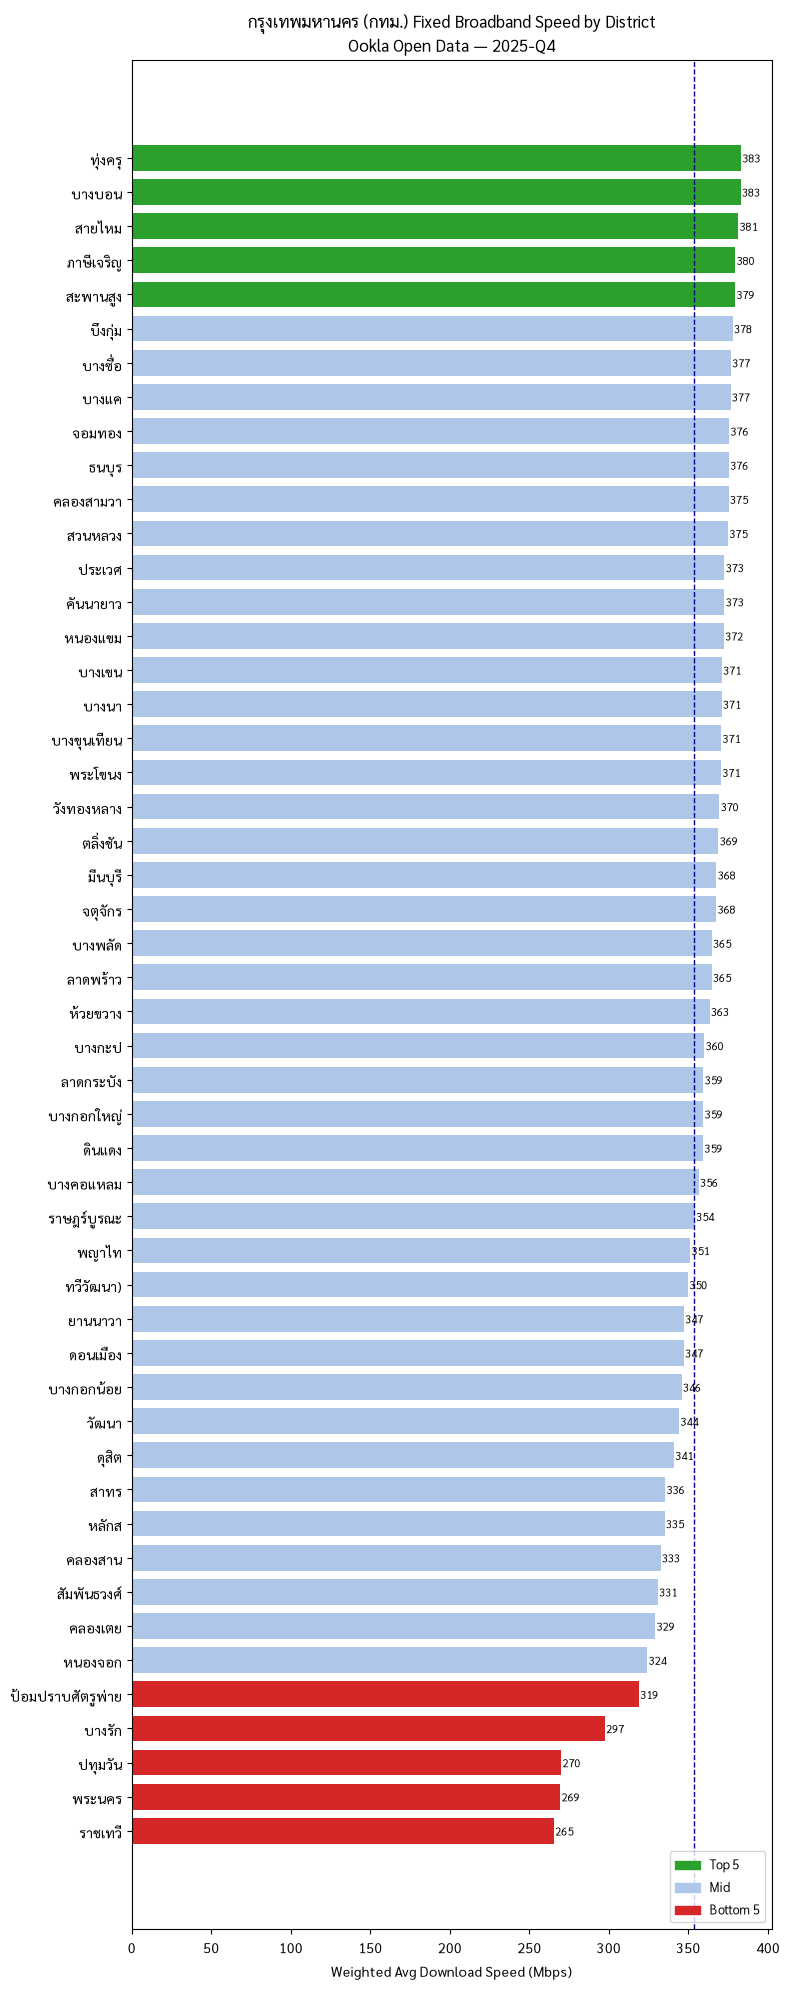

Saved: ../../outputs/ookla/bangkokmetropolis_district_fixed_ranking_2025-Q4.png


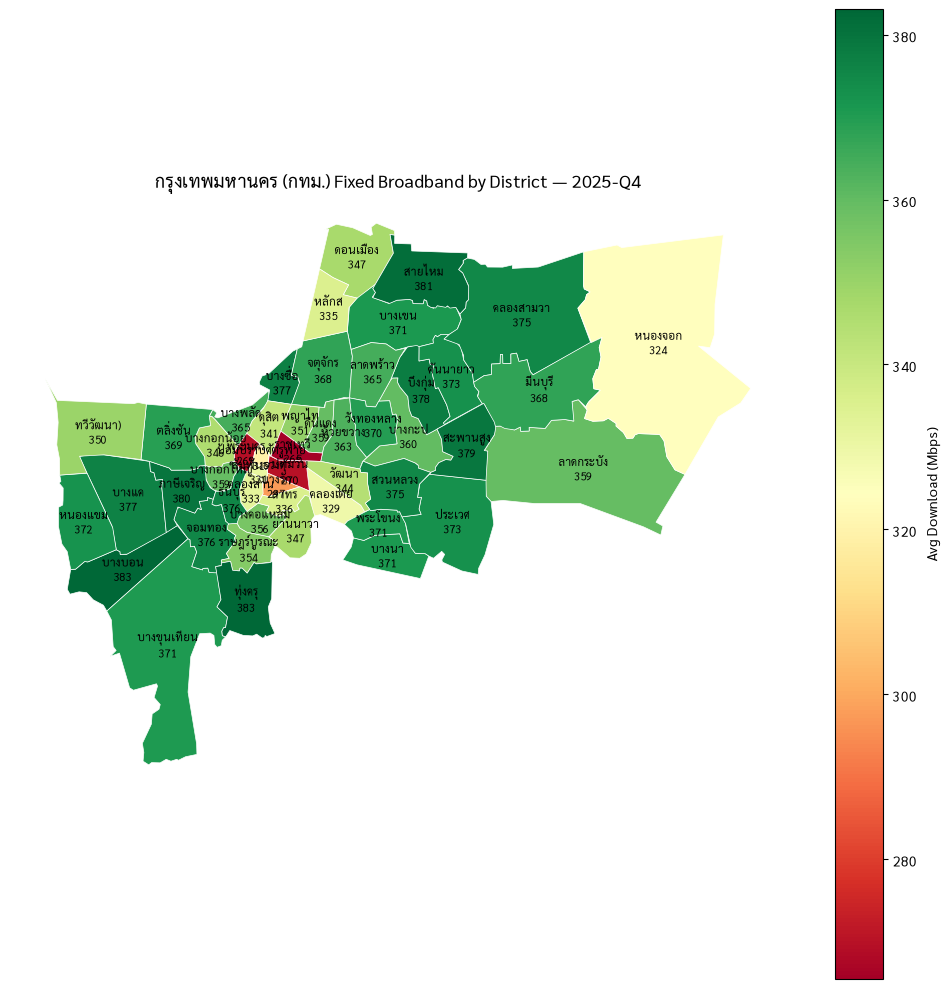

Saved: ../../outputs/ookla/bangkokmetropolis_district_fixed_map_2025-Q4.png
Saved: ../../data/exports/bangkokmetropolis_district_fixed_2025-Q4.csv


In [5]:
stats_bangkok = analyze_province_districts('BangkokMetropolis', 'กรุงเทพมหานคร', 'กทม.')


## นครราชสีมา (โคราช) — Northeastern

=== นครราชสีมา (โคราช) — 32 districts ===
Bbox: lon 101.1830–103.0140, lat 14.1194–15.8065
Tiles in bbox: 7,354


Tiles matched to districts: 4,980 | Districts covered: 32/32

=== TOP 5 (นครราชสีมา (โคราช)) ===
 rank        name_en     name_th  avg_d_mbps  total_tests
    1    KhamThalaSo   ขามทะเลสอ  386.792175        320.0
    2       K.BuaLai  กิ่งบัวลาย  384.607363         91.0
    3 KaengSanamNang แก้งสนามนาง  368.975368        133.0
    4        NonSung      โนนสูง  362.271793        800.0
    5     ChumPhuang      ชุมพวง  361.340777        359.0

=== BOTTOM 5 (นครราชสีมา (โคราช)) ===
 rank         name_en        name_th  avg_d_mbps  total_tests
   28    WangNumKhiaw    วังน้ำเขียว  268.523198        701.0
   29     HuaiThalang       ห้วยแถลง  263.551658        371.0
   30     K.ThePhaRak  กิ่งเทพารักษ์  260.079071        156.0
   31 Chalermphrakiet         ชุมพวง  257.721892        406.0
   32 K.LamThaMenChai กิ่งลำทะเมนชัย  243.758756        135.0


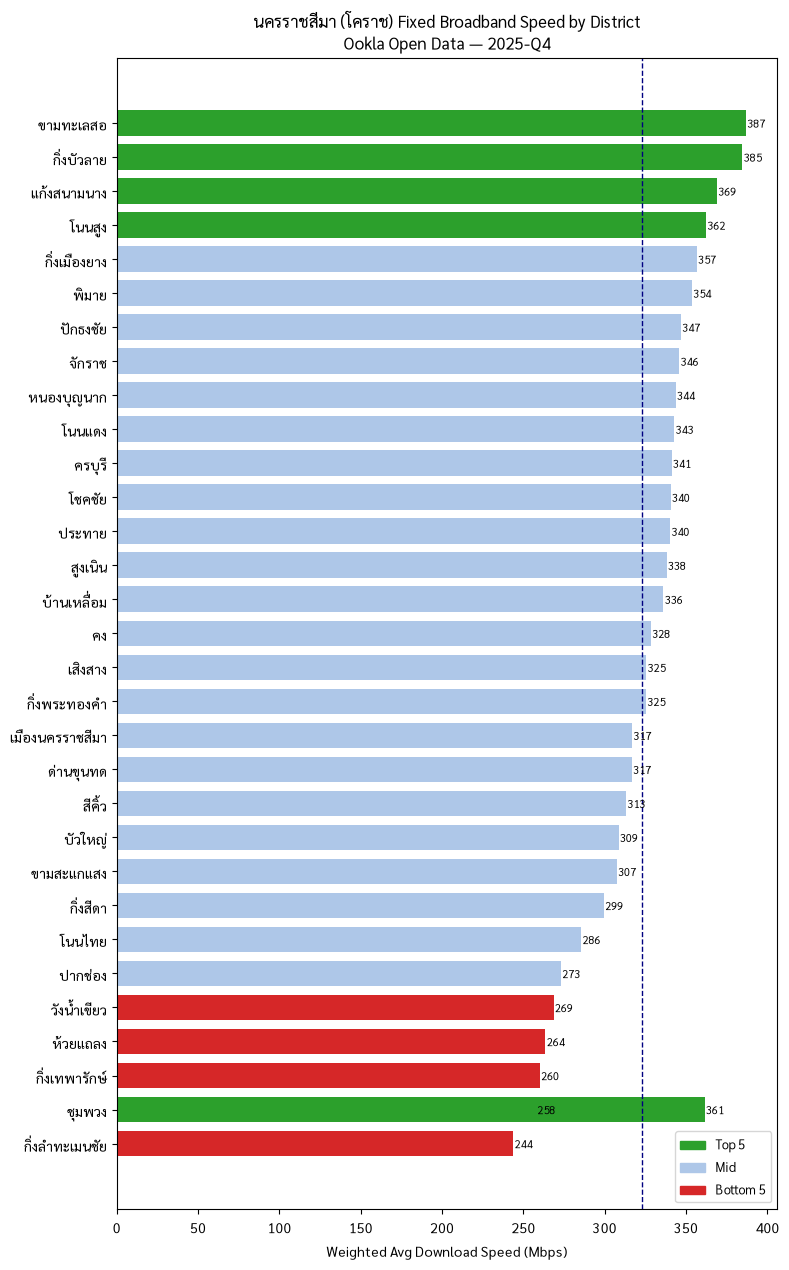

Saved: ../../outputs/ookla/nakhonratchasima_district_fixed_ranking_2025-Q4.png


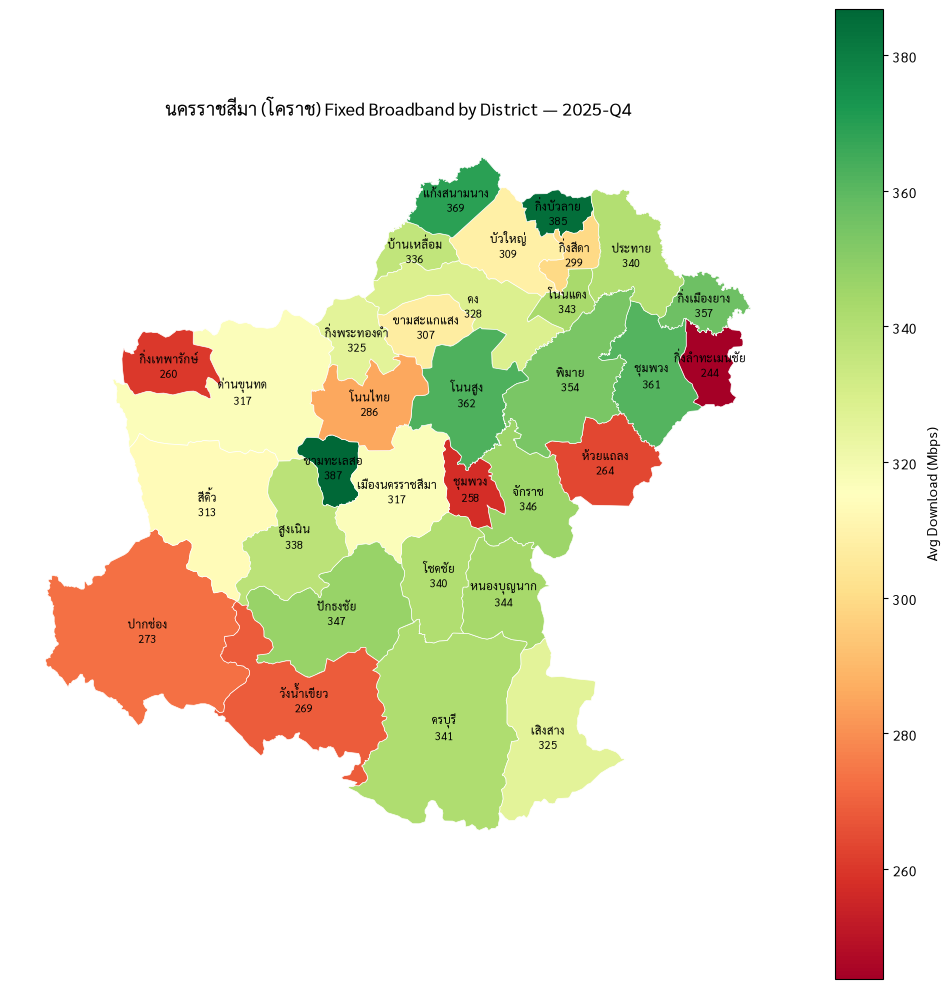

Saved: ../../outputs/ookla/nakhonratchasima_district_fixed_map_2025-Q4.png
Saved: ../../data/exports/nakhonratchasima_district_fixed_2025-Q4.csv


In [6]:
stats_nakhonratchasima = analyze_province_districts('NakhonRatchasima', 'นครราชสีมา', 'โคราช')


## ขอนแก่น — Northeastern

=== ขอนแก่น — 26 districts ===
Bbox: lon 101.7497–103.1880, lat 15.6309–17.0872
Tiles in bbox: 4,049


Tiles matched to districts: 2,146 | Districts covered: 26/26

=== TOP 5 (ขอนแก่น) ===
 rank     name_en     name_th  avg_d_mbps  total_tests
    1   K.NonSila กิ่งโนนศิลา  466.178778        176.0
    2    WaengNoi     แวงน้อย  348.020253         91.0
    3     PhraYun      พระยืน  326.204379        169.0
    4 ManchaKhiri   มัญจาคีรี  320.707538        418.0
    5     Kranuan      กระนวน  320.363069        550.0

=== BOTTOM 5 (ขอนแก่น) ===
 rank   name_en     name_th  avg_d_mbps  total_tests
   22 Chonnabot        ชนบท  228.767533        336.0
   23 K.BanHaet กิ่งบ้านแฮด  220.136607        112.0
   24  NamPhong      น้ำพอง  203.910032        834.0
   25  PhupaMan    ภูผาม่าน  174.694844        262.0
   26   PuaiNoi   เปือยน้อย  165.482227         22.0


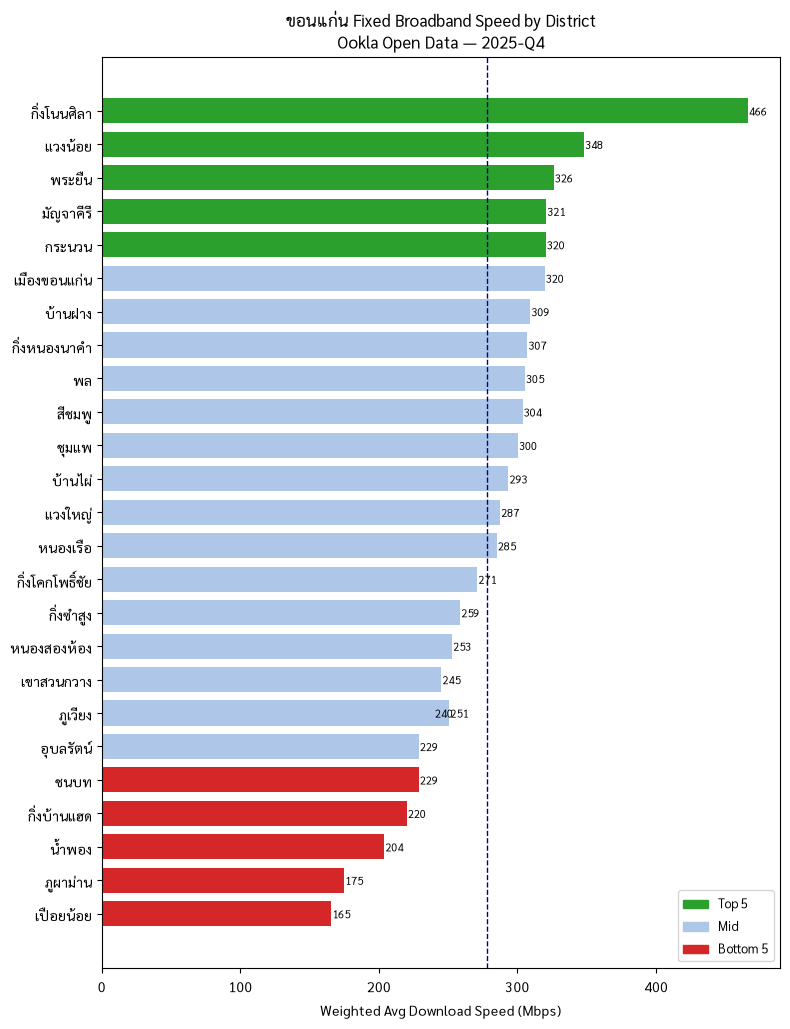

Saved: ../../outputs/ookla/khonkaen_district_fixed_ranking_2025-Q4.png


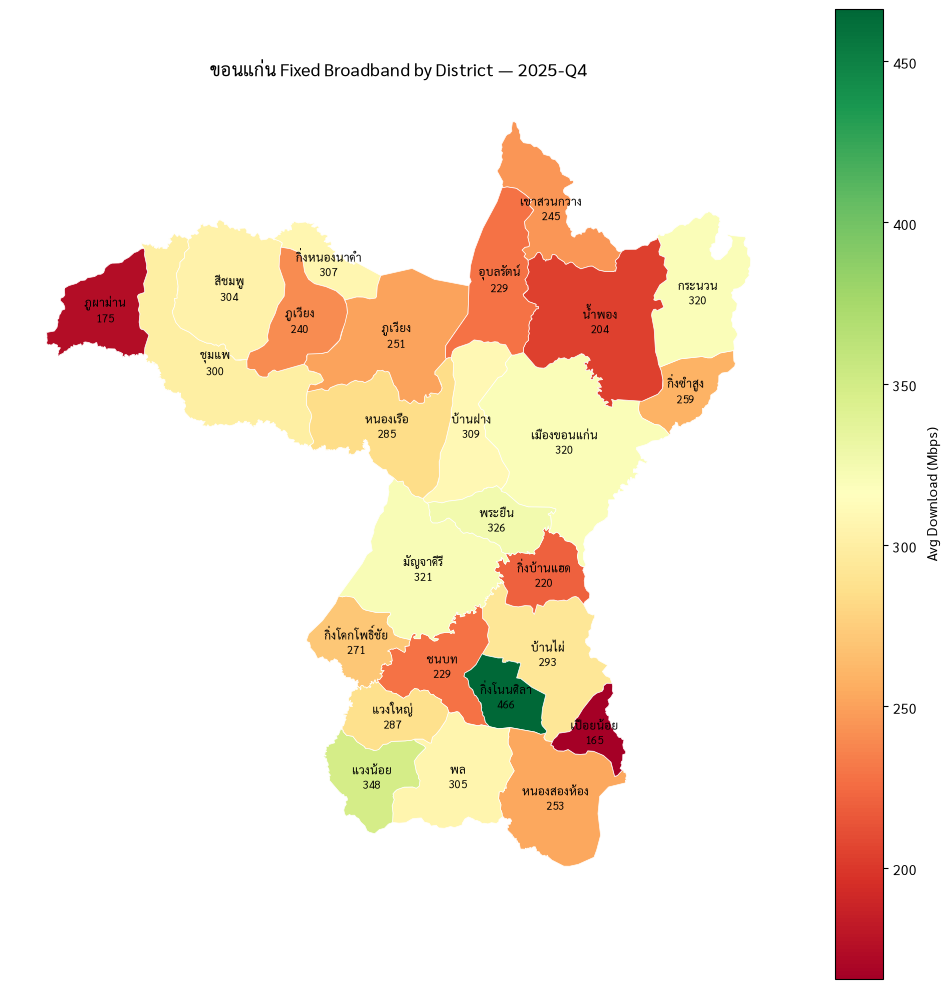

Saved: ../../outputs/ookla/khonkaen_district_fixed_map_2025-Q4.png
Saved: ../../data/exports/khonkaen_district_fixed_2025-Q4.csv


In [7]:
stats_khonkaen = analyze_province_districts('KhonKaen', 'ขอนแก่น', None)


## เชียงใหม่ — Northern

=== เชียงใหม่ — 24 districts ===
Bbox: lon 98.0098–99.5739, lat 17.2727–20.1442
Tiles in bbox: 6,527


Tiles matched to districts: 4,114 | Districts covered: 24/24

=== TOP 5 (เชียงใหม่) ===
 rank      name_en   name_th  avg_d_mbps  total_tests
    1 SanKamphaeng  สันกำแพง  354.139653       4155.0
    2      Saraphi     สารภี  348.597504       5003.0
    3     HangDong     หางดง  347.204252       5541.0
    4       SanSai   สันทราย  343.895688       8167.0
    5     DoiSaket ดอยสะเก็ด  331.147908       3983.0

=== BOTTOM 5 (เชียงใหม่) ===
 rank  name_en name_th  avg_d_mbps  total_tests
   20   DoiTao ดอยเต่า  174.698744        129.0
   21  Samoeng  สะเมิง  169.433606        498.0
   22      Hot     ฮอด  150.327160        462.0
   23 MaeChaem แม่แจ่ม  149.022352       1062.0
   24    Omkoi  อมก๋อย   78.579815        697.0


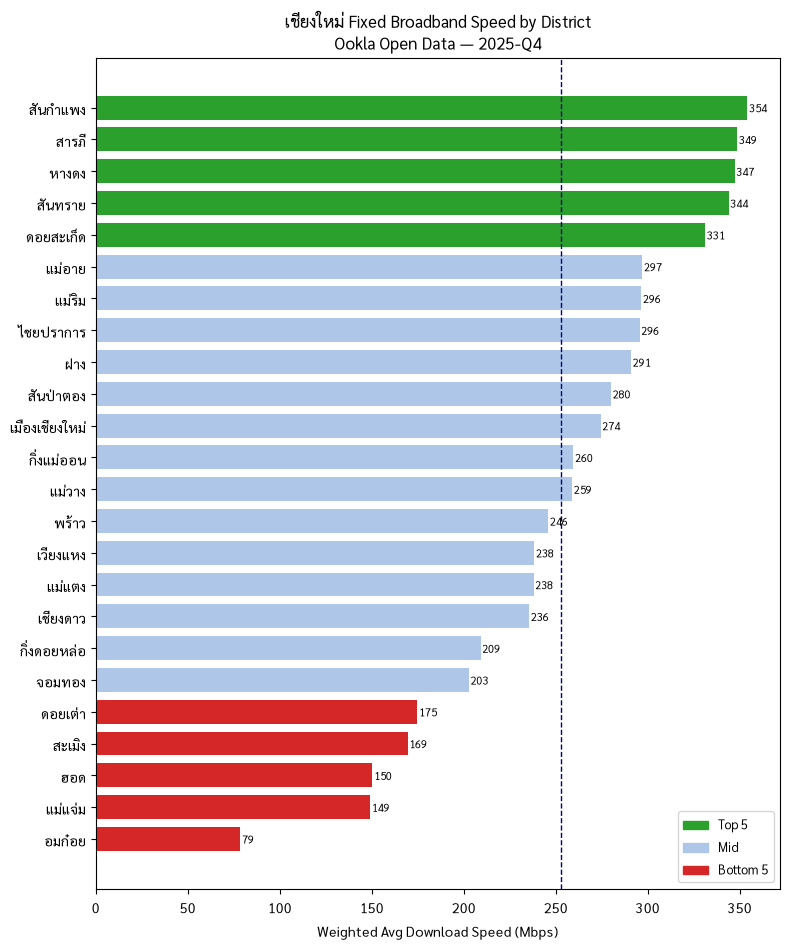

Saved: ../../outputs/ookla/chiangmai_district_fixed_ranking_2025-Q4.png


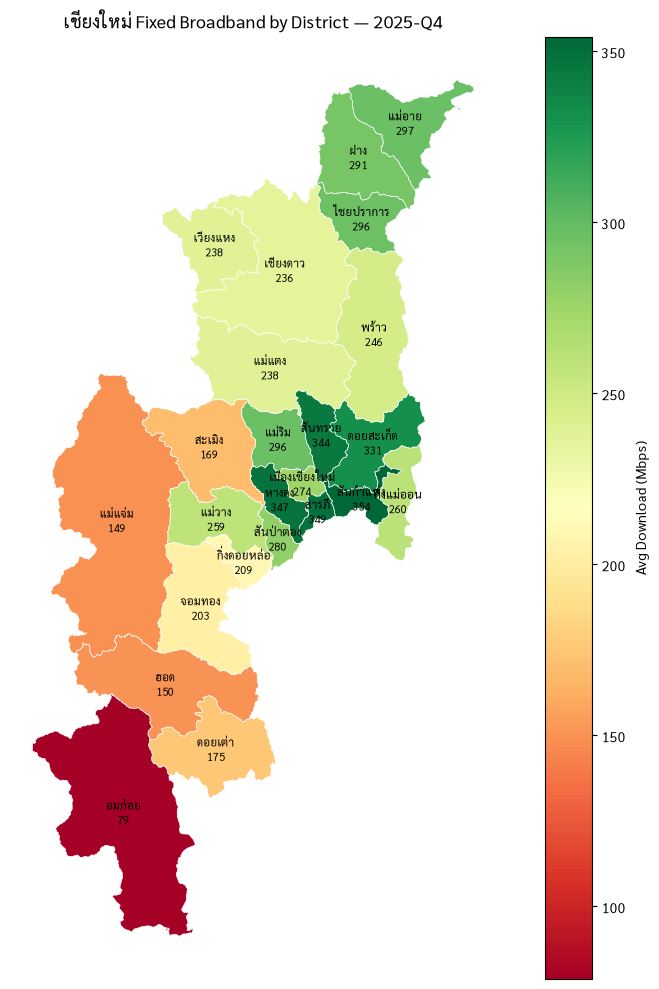

Saved: ../../outputs/ookla/chiangmai_district_fixed_map_2025-Q4.png
Saved: ../../data/exports/chiangmai_district_fixed_2025-Q4.csv


In [8]:
stats_chiangmai = analyze_province_districts('ChiangMai', 'เชียงใหม่', None)


## ภูเก็ต — Southern

=== ภูเก็ต — 3 districts ===
Bbox: lon 98.2581–98.6162, lat 7.4613–8.1999
Tiles in bbox: 1,055


Tiles matched to districts: 895 | Districts covered: 3/3

=== TOP 1 (ภูเก็ต) ===


 rank name_en name_th  avg_d_mbps  total_tests
    1 Thalang    ถลาง  290.932416      12655.0

=== BOTTOM 1 (ภูเก็ต) ===
 rank name_en name_th  avg_d_mbps  total_tests
    3   Kathu   กะทู้  243.635726       9126.0


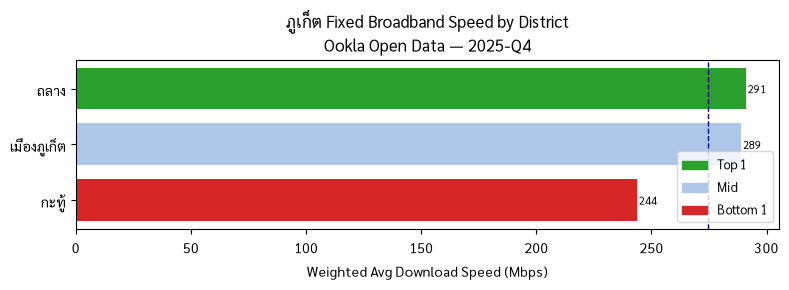

Saved: ../../outputs/ookla/phuket_district_fixed_ranking_2025-Q4.png


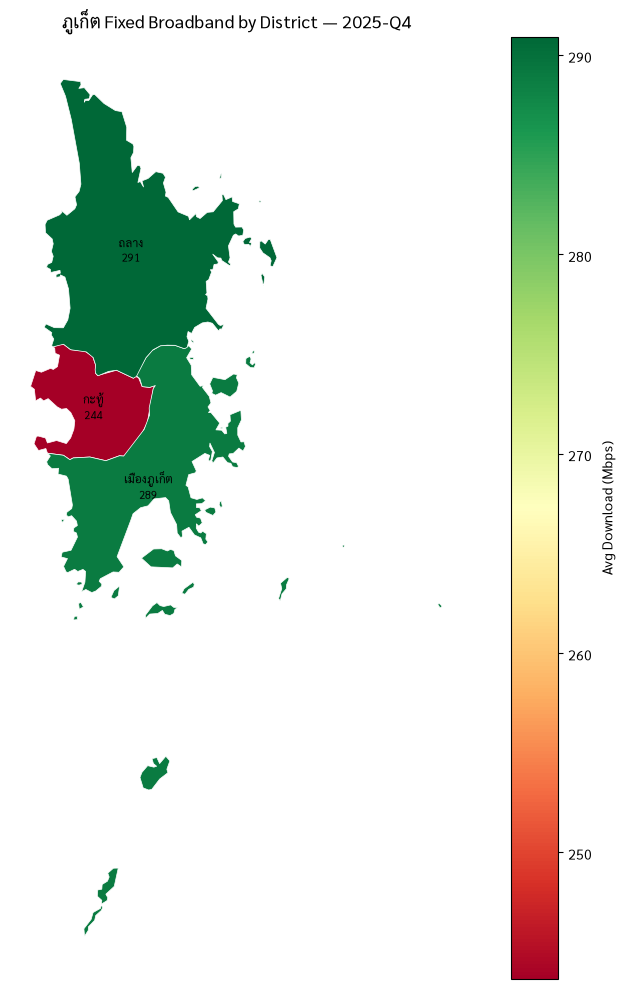

Saved: ../../outputs/ookla/phuket_district_fixed_map_2025-Q4.png
Saved: ../../data/exports/phuket_district_fixed_2025-Q4.csv


In [9]:
stats_phuket = analyze_province_districts('Phuket', 'ภูเก็ต', None)


## ชลบุรี — Eastern (EEC)

=== ชลบุรี — 11 districts ===
Bbox: lon 100.6477–101.7201, lat 12.5079–13.5986
Tiles in bbox: 7,966


Tiles matched to districts: 4,075 | Districts covered: 11/11

=== TOP 5 (ชลบุรี) ===
 rank       name_en        name_th  avg_d_mbps  total_tests
    1     PhanThong         พานทอง  367.065638       3884.0
    2       SiRacha        ศรีราชา  357.818197      18123.0
    3 MuangChonBuri    เมืองชลบุรี  350.601620      24833.0
    4      K.KoChan กิ่งเกาะจันทร์  343.117129        634.0
    5       BanBung        บ้านบึง  334.976080       4564.0

=== BOTTOM 5 (ชลบุรี) ===
 rank      name_en   name_th  avg_d_mbps  total_tests
    7 PhanatNikhom  พนัสนิคม  319.968359       2807.0
    8      NongYai  หนองใหญ่  313.021319        630.0
    9      BoThong    บ่อทอง  299.811448        841.0
   10   BangLamung  บางละมุง  293.924536      43997.0
   11    KoSichang เกาะสีชัง  291.981069        116.0


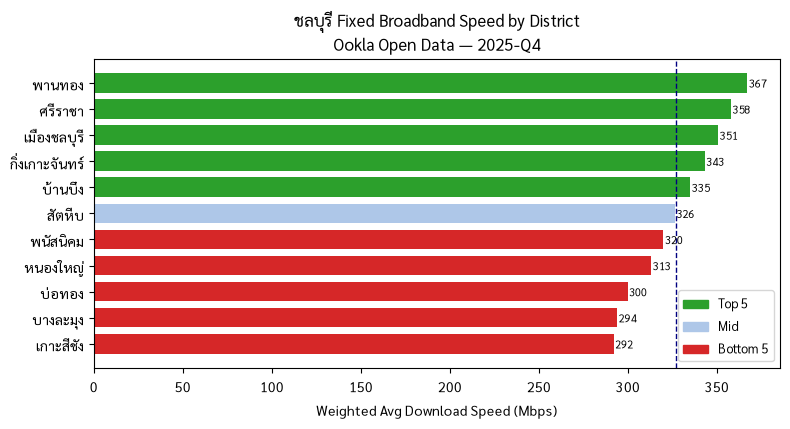

Saved: ../../outputs/ookla/chonburi_district_fixed_ranking_2025-Q4.png


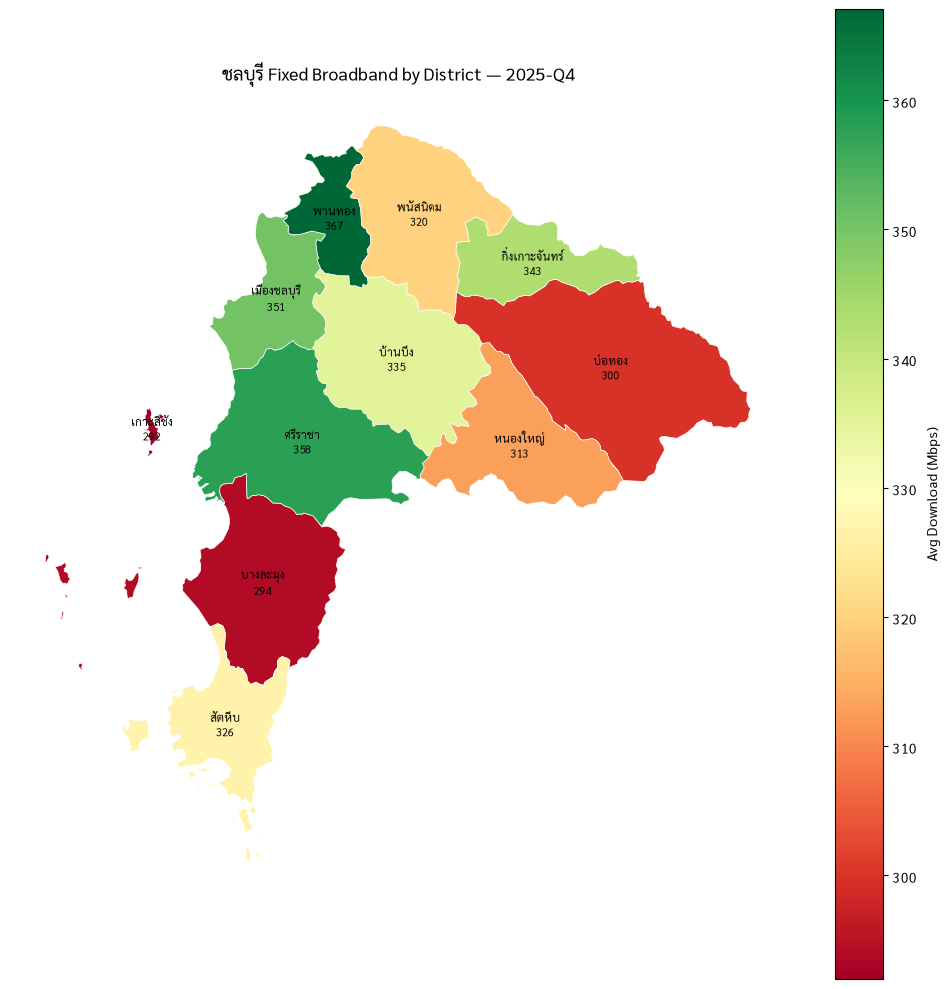

Saved: ../../outputs/ookla/chonburi_district_fixed_map_2025-Q4.png
Saved: ../../data/exports/chonburi_district_fixed_2025-Q4.csv


In [10]:
stats_chonburi = analyze_province_districts('ChonBuri', 'ชลบุรี', None)


## สงขลา — Southern

=== สงขลา — 17 districts ===
Bbox: lon 100.0546–101.1123, lat 6.2887–7.9368
Tiles in bbox: 3,628


Tiles matched to districts: 2,258 | Districts covered: 17/17



=== TOP 5 (สงขลา) ===
 rank       name_en     name_th  avg_d_mbps  total_tests
    1      BangKlam     บางกล่ำ  354.124248        642.0
    2    KhuanNiang    ควนเนียง  353.019679        340.0
    3  SinghaNakhon     สิงหนคร  351.683749        941.0
    4        HatYai     หาดใหญ่  323.237794      18408.0
    5 KhlongHoiKong คลองหอยโข่ง  317.999515        814.0

=== BOTTOM 5 (สงขลา) ===
 rank     name_en   name_th  avg_d_mbps  total_tests
   13 SathingPhra   สทิงพระ  242.963663        359.0
   14   Rattaphum   รัตภูมิ  237.757518        654.0
   15       Ranot     ระโนด  233.251668        392.0
   16     SabaYoi สะบ้าย้อย  228.186222        338.0
   17      Thepha      เทพา  201.364149        456.0


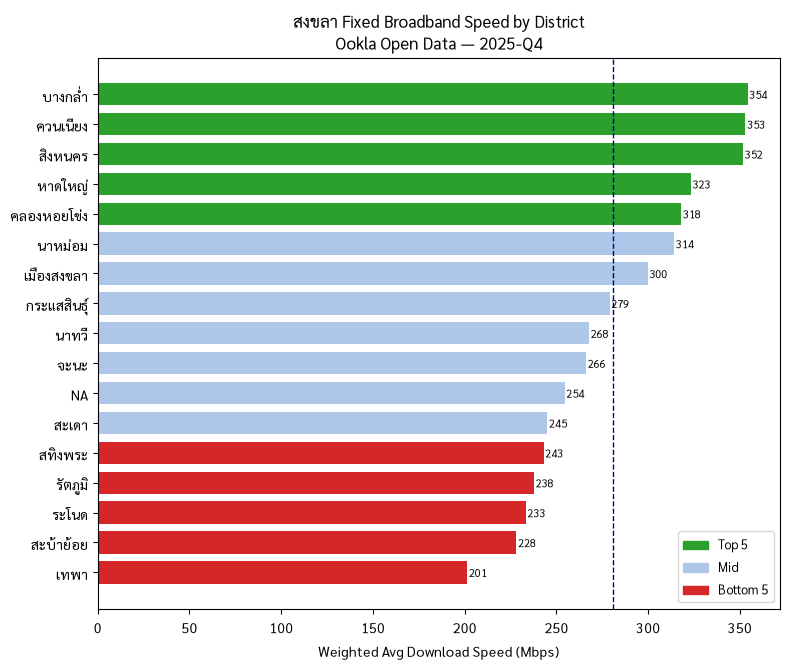

Saved: ../../outputs/ookla/songkhla_district_fixed_ranking_2025-Q4.png


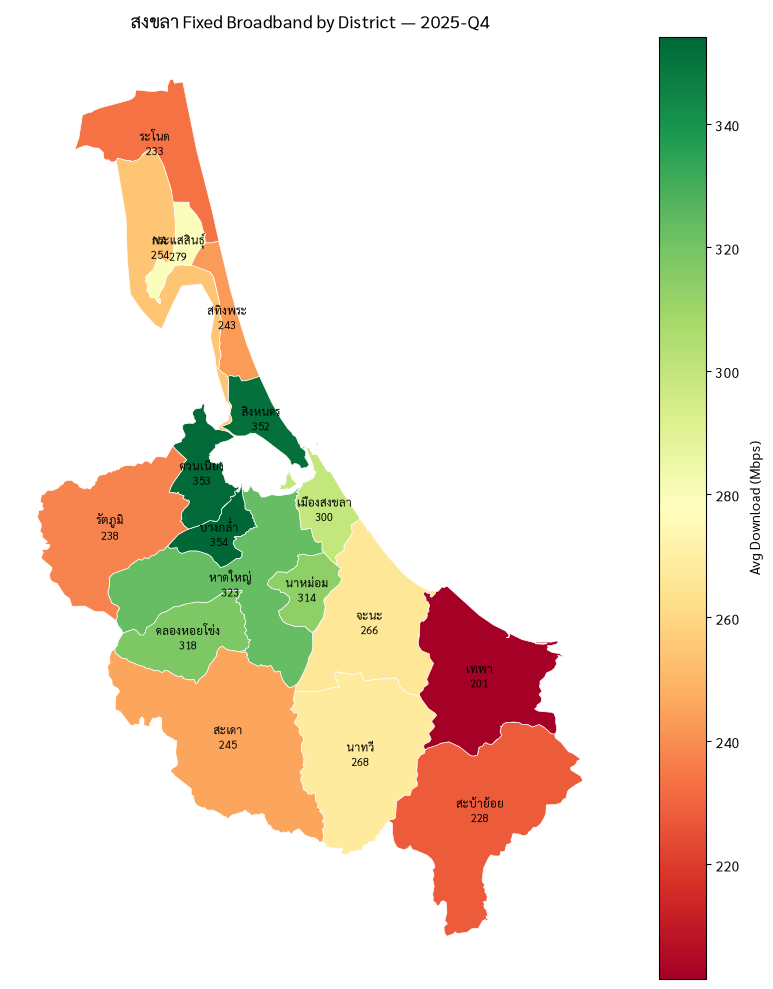

Saved: ../../outputs/ookla/songkhla_district_fixed_map_2025-Q4.png
Saved: ../../data/exports/songkhla_district_fixed_2025-Q4.csv


In [11]:
stats_songkhla = analyze_province_districts('Songkhla', 'สงขลา', None)


## ระยอง — Eastern (EEC)

=== ระยอง — 8 districts ===
Bbox: lon 100.9857–101.8320, lat 12.5127–13.1631
Tiles in bbox: 3,632


Tiles matched to districts: 2,886 | Districts covered: 8/8

=== TOP 4 (ระยอง) ===
 rank      name_en      name_th  avg_d_mbps  total_tests
    1 K.KhaoChamao กิ่งเขาชะเมา  391.769742        271.0
    2      BanKhai     บ้านค่าย  363.774398       2105.0
    3   PluakDaeng      ปลวกแดง  361.151330       6153.0
    4     BanChang      บ้านฉาง  349.776826       3565.0

=== BOTTOM 4 (ระยอง) ===
 rank        name_en       name_th  avg_d_mbps  total_tests
    5 K.NikhomPattan กิ่งนิคมพัฒนา  347.517895       3052.0
    6       WangChan     วังจันทร์  345.235255        534.0
    7         Klaeng          แกลง  328.103277       3111.0
    8    MuangRayong    เมืองระยอง  318.439472      17060.0


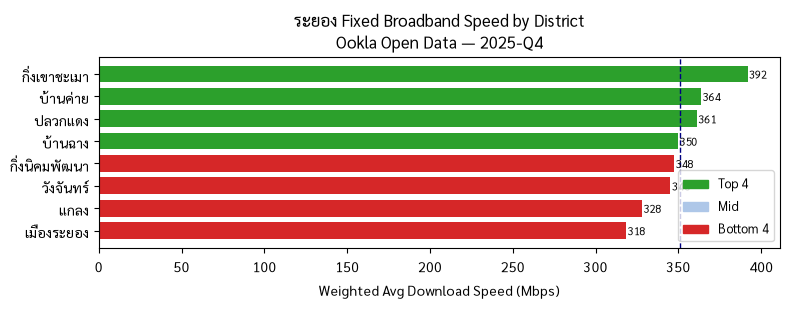

Saved: ../../outputs/ookla/rayong_district_fixed_ranking_2025-Q4.png


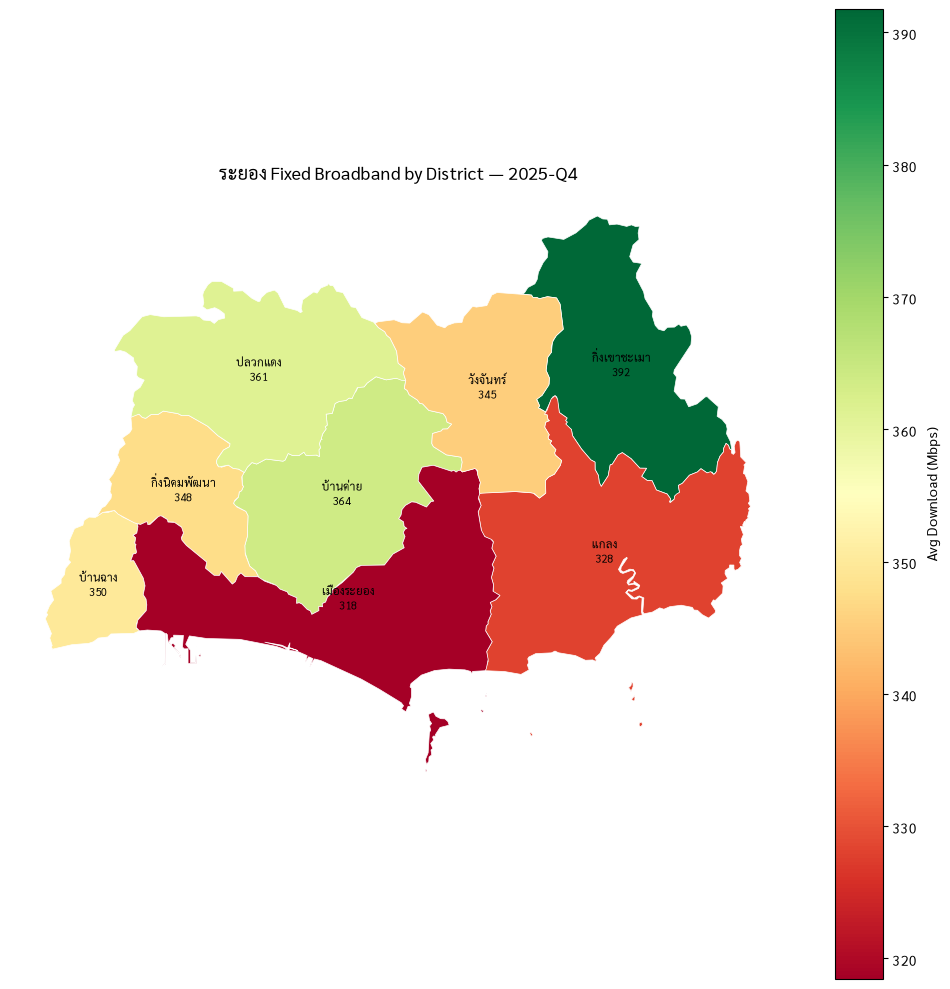

Saved: ../../outputs/ookla/rayong_district_fixed_map_2025-Q4.png
Saved: ../../data/exports/rayong_district_fixed_2025-Q4.csv


In [12]:
stats_rayong = analyze_province_districts('Rayong', 'ระยอง', None)


## Cross-Province Comparison

รวมผลทั้ง 8 จังหวัด เทียบ average download speed ระดับจังหวัด (ถ่วงน้ำหนักจากอำเภอ) เพื่อดูภาพรวมก่อนเทียบกับผล NDT7

      province_en   province_th  avg_d_mbps  total_tests  n_districts  rank
BangkokMetropolis กรุงเทพมหานคร  357.667377     475701.0         50.0     1
           Rayong         ระยอง  335.815463      35851.0          8.0     2
         ChonBuri        ชลบุรี  325.449917     109012.0         11.0     3
 NakhonRatchasima    นครราชสีมา  311.163899      41791.0         32.0     4
         Songkhla         สงขลา  308.419738      30946.0         17.0     5
         KhonKaen       ขอนแก่น  305.738347      21613.0         26.0     6
        ChiangMai     เชียงใหม่  294.779508      70005.0         24.0     7
           Phuket        ภูเก็ต  279.829609      42691.0          3.0     8


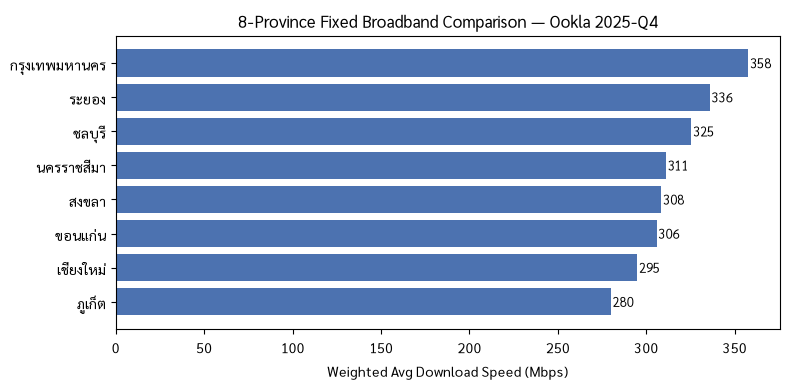

Saved: ../../outputs/ookla/8province_district_comparison_2025-Q4.png
Saved: ../../data/exports/8province_summary_2025-Q4.csv


In [13]:
all_stats = pd.concat([stats_bangkok, stats_nakhonratchasima, stats_khonkaen, stats_chiangmai, stats_phuket, stats_chonburi, stats_songkhla, stats_rayong], ignore_index=True)

province_summary = (
    all_stats.groupby(['province_en', 'province_th'])
    .apply(
        lambda x: pd.Series({
            METRIC_MBPS: np.average(x[METRIC_MBPS], weights=x['total_tests']),
            'total_tests': x['total_tests'].sum(),
            'n_districts': len(x),
        }),
        include_groups=False,
    )
    .reset_index()
    .sort_values(METRIC_MBPS, ascending=False)
    .reset_index(drop=True)
)
province_summary['rank'] = province_summary[METRIC_MBPS].rank(ascending=False).astype(int)

print(province_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
df_plot = province_summary.sort_values(METRIC_MBPS, ascending=True)
bars = ax.barh(df_plot['province_th'], df_plot[METRIC_MBPS], color='#4c72b0')
for bar, val in zip(bars, df_plot[METRIC_MBPS]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}', va='center', ha='left', fontsize=9)
ax.set_xlabel('Weighted Avg Download Speed (Mbps)')
ax.set_title(f'8-Province Fixed Broadband Comparison — Ookla {QUARTER}')
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, f'8province_district_comparison_{QUARTER}.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

out_csv = os.path.join(EXPORT_DIR, f'8province_summary_{QUARTER}.csv')
all_stats.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')


---
# Part 2 — Mobile/Cellular


### Config

In [14]:
DISTRICTS_GEOJSON = '../../data/geo/thailand_districts.json'
OOKLA_RAW_DIR     = '../../data/ookla/raw'
OUTPUT_DIR        = '../../outputs/ookla'
EXPORT_DIR        = '../../data/exports'

QUARTER = '2025-Q4'  # change to use different quarter
PARQUET  = os.path.join(OOKLA_RAW_DIR, f'{QUARTER}_performance_mobile_tiles.parquet')

METRIC_RAW  = 'avg_d_kbps'
METRIC_MBPS = 'avg_d_mbps'

# 7 target provinces: (NAME_1 in GADM, Thai display name, common/colloquial name)
PROVINCES = [
    ('BangkokMetropolis', 'กรุงเทพมหานคร', 'กทม.'),
    ('NakhonRatchasima', 'นครราชสีมา', 'โคราช'),
    ('KhonKaen',         'ขอนแก่น',    None),
    ('ChiangMai',        'เชียงใหม่',   None),
    ('Phuket',           'ภูเก็ต',      None),
    ('ChonBuri',         'ชลบุรี',      None),
    ('Songkhla',         'สงขลา',      None),
    ('Rayong',           'ระยอง',      None),
]

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)


### Load Thailand District Boundaries (GADM Level 2)

In [15]:
thai_districts_gdf = gpd.read_file(DISTRICTS_GEOJSON).to_crs(4326)
thai_districts_gdf = thai_districts_gdf.rename(columns={'NAME_2': 'name_en', 'NL_NAME_2': 'name_th'})
thai_districts_gdf['name_th'] = thai_districts_gdf['name_th'].str.replace('อำเภอ', '', regex=False).str.strip()

print(f'Total districts loaded (all Thailand): {len(thai_districts_gdf):,}')
print(f'Provinces available: {thai_districts_gdf["NAME_1"].nunique()}')


Total districts loaded (all Thailand): 928
Provinces available: 77


### Reusable Pipeline — Province → District-Level Mobile/Cellular Stats

_One shared pipeline for all 8 provinces, Bangkok included._

In [16]:
def analyze_province_districts(name_1, th_name, common_name=None):
    label = f'{th_name} ({common_name})' if common_name else th_name

    # District boundaries for this province
    prov_gdf = thai_districts_gdf[thai_districts_gdf['NAME_1'] == name_1][['name_en', 'name_th', 'geometry']].copy()
    bounds = prov_gdf.total_bounds  # [min_lon, min_lat, max_lon, max_lat]
    n_districts = len(prov_gdf)

    print(f'=== {label} — {n_districts} districts ===')
    print(f'Bbox: lon {bounds[0]:.4f}–{bounds[2]:.4f}, lat {bounds[1]:.4f}–{bounds[3]:.4f}')

    # Ookla tiles within province bbox
    bbox_filters = [
        ('tile_y', '<=', bounds[3]),
        ('tile_y', '>=', bounds[1]),
        ('tile_x', '<=', bounds[2]),
        ('tile_x', '>=', bounds[0]),
    ]
    tiles_df = pd.read_parquet(PARQUET, columns=['tile_x', 'tile_y', 'tests', METRIC_RAW], filters=bbox_filters)
    print(f'Tiles in bbox: {len(tiles_df):,}')
    
    tiles_gdf = gpd.GeoDataFrame(
        tiles_df,
        geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y),
        crs='EPSG:4326',
    ).drop(columns=['tile_x', 'tile_y'])
    tiles_gdf.dropna(subset=[METRIC_RAW], inplace=True)

    # Spatial join tiles -> districts
    joined = gpd.sjoin(
        tiles_gdf, prov_gdf[['name_en', 'name_th', 'geometry']],
        how='inner', predicate='intersects',
    )[['name_en', 'name_th', 'tests', METRIC_RAW]]
    print(f'Tiles matched to districts: {len(joined):,} | Districts covered: {joined["name_en"].nunique()}/{n_districts}')

    if joined.empty:
        print(f'⚠ No tiles matched for {label} — skipping.')
        return pd.DataFrame()

    # Weighted average per district
    district_stats = (
        joined.groupby(['name_en', 'name_th'])
        .apply(
            lambda x: pd.Series({
                METRIC_MBPS: np.average(x[METRIC_RAW], weights=x['tests']) / 1000,
                'total_tests': x['tests'].sum(),
                'n_tiles': len(x),
            }),
            include_groups=False,
        )
        .reset_index()
        .sort_values(METRIC_MBPS, ascending=False)
        .reset_index(drop=True)
    )
    district_stats['rank'] = district_stats[METRIC_MBPS].rank(ascending=False).astype(int)

    k = min(5, max(1, len(district_stats) // 2))
    print(f'\n=== TOP {k} ({label}) ===')
    print(district_stats.head(k)[['rank', 'name_en', 'name_th', METRIC_MBPS, 'total_tests']].to_string(index=False))
    print(f'\n=== BOTTOM {k} ({label}) ===')
    print(district_stats.tail(k)[['rank', 'name_en', 'name_th', METRIC_MBPS, 'total_tests']].to_string(index=False))

    # Bar chart — all districts ranked
    df_plot = district_stats.sort_values(METRIC_MBPS, ascending=True)
    labels = df_plot['name_th'].tolist()
    values = df_plot[METRIC_MBPS].tolist()
    n = len(df_plot)
    colors = ['#d62728' if i < k else ('#2ca02c' if i >= n - k else '#aec7e8') for i in range(n)]

    fig, ax = plt.subplots(figsize=(8, max(3, n * 0.4)))
    bars = ax.barh(labels, values, color=colors, edgecolor='none', height=0.75)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}', va='center', ha='left', fontsize=8)
    ax.set_xlabel('Weighted Avg Download Speed (Mbps)', fontsize=10)
    ax.set_title(f'{label} Mobile/Cellular Speed by District\nOokla Open Data — {QUARTER}', fontsize=12)
    ax.axvline(district_stats[METRIC_MBPS].mean(), color='navy', linestyle='--', linewidth=1)
    patches = [
        mpatches.Patch(color='#2ca02c', label=f'Top {k}'),
        mpatches.Patch(color='#aec7e8', label='Mid'),
        mpatches.Patch(color='#d62728', label=f'Bottom {k}'),
    ]
    ax.legend(handles=patches, fontsize=9, loc='lower right')
    plt.tight_layout()
    slug = name_1.lower()
    out = os.path.join(OUTPUT_DIR, f'{slug}_district_mobile_ranking_{QUARTER}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

    # Choropleth map
    district_geo = prov_gdf.merge(district_stats, on=['name_en', 'name_th'], how='left')
    fig, ax = plt.subplots(1, figsize=(10, 10))
    district_geo.plot(
        column=METRIC_MBPS, ax=ax, cmap='RdYlGn', legend=True,
        legend_kwds={'label': 'Avg Download (Mbps)', 'orientation': 'vertical'},
        edgecolor='white', linewidth=0.5,
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    )
    for _, row in district_geo.iterrows():
        if pd.notna(row[METRIC_MBPS]):
            c = row.geometry.centroid
            ax.annotate(f"{row['name_th']}\n{row[METRIC_MBPS]:.0f}", xy=(c.x, c.y), ha='center', va='center', fontsize=8, color='black')
    ax.set_title(f'{label} Mobile/Cellular by District — {QUARTER}', fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    out_map = os.path.join(OUTPUT_DIR, f'{slug}_district_mobile_map_{QUARTER}.png')
    plt.savefig(out_map, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_map}')

    # Export CSV
    out_csv = os.path.join(EXPORT_DIR, f'{slug}_district_mobile_{QUARTER}.csv')
    district_stats.to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

    return district_stats.assign(province_en=name_1, province_th=th_name)


## กรุงเทพมหานคร (กทม.) — Bangkok & Vicinity


=== กรุงเทพมหานคร (กทม.) — 50 districts ===
Bbox: lon 100.3200–100.9391, lat 13.4925–13.9543
Tiles in bbox: 6,655


Tiles matched to districts: 3,524 | Districts covered: 50/50



=== TOP 5 (กรุงเทพมหานคร (กทม.)) ===
 rank    name_en name_th  avg_d_mbps  total_tests
    1  PhayaThai   พญาไท  263.790215       2750.0
    2 PhraNakhon  พระนคร  216.561746       1310.0
    3    BangRak  บางรัก  210.286836       3091.0
    4  PathumWan ปทุมวัน  208.779180       8387.0
    5      Dusit   ดุสิต  208.136658       2415.0

=== BOTTOM 5 (กรุงเทพมหานคร (กทม.)) ===
 rank    name_en   name_th  avg_d_mbps  total_tests
   46 LatKrabang ลาดกระบัง  133.668157       5143.0
   47  Nongkheam   หนองแขม  132.376003       2071.0
   48    MinBuri   มีนบุรี  126.960385       2004.0
   49     SaiMai    สายไหม  124.809261       3365.0
   50   NongChok   หนองจอก   83.927135       2893.0


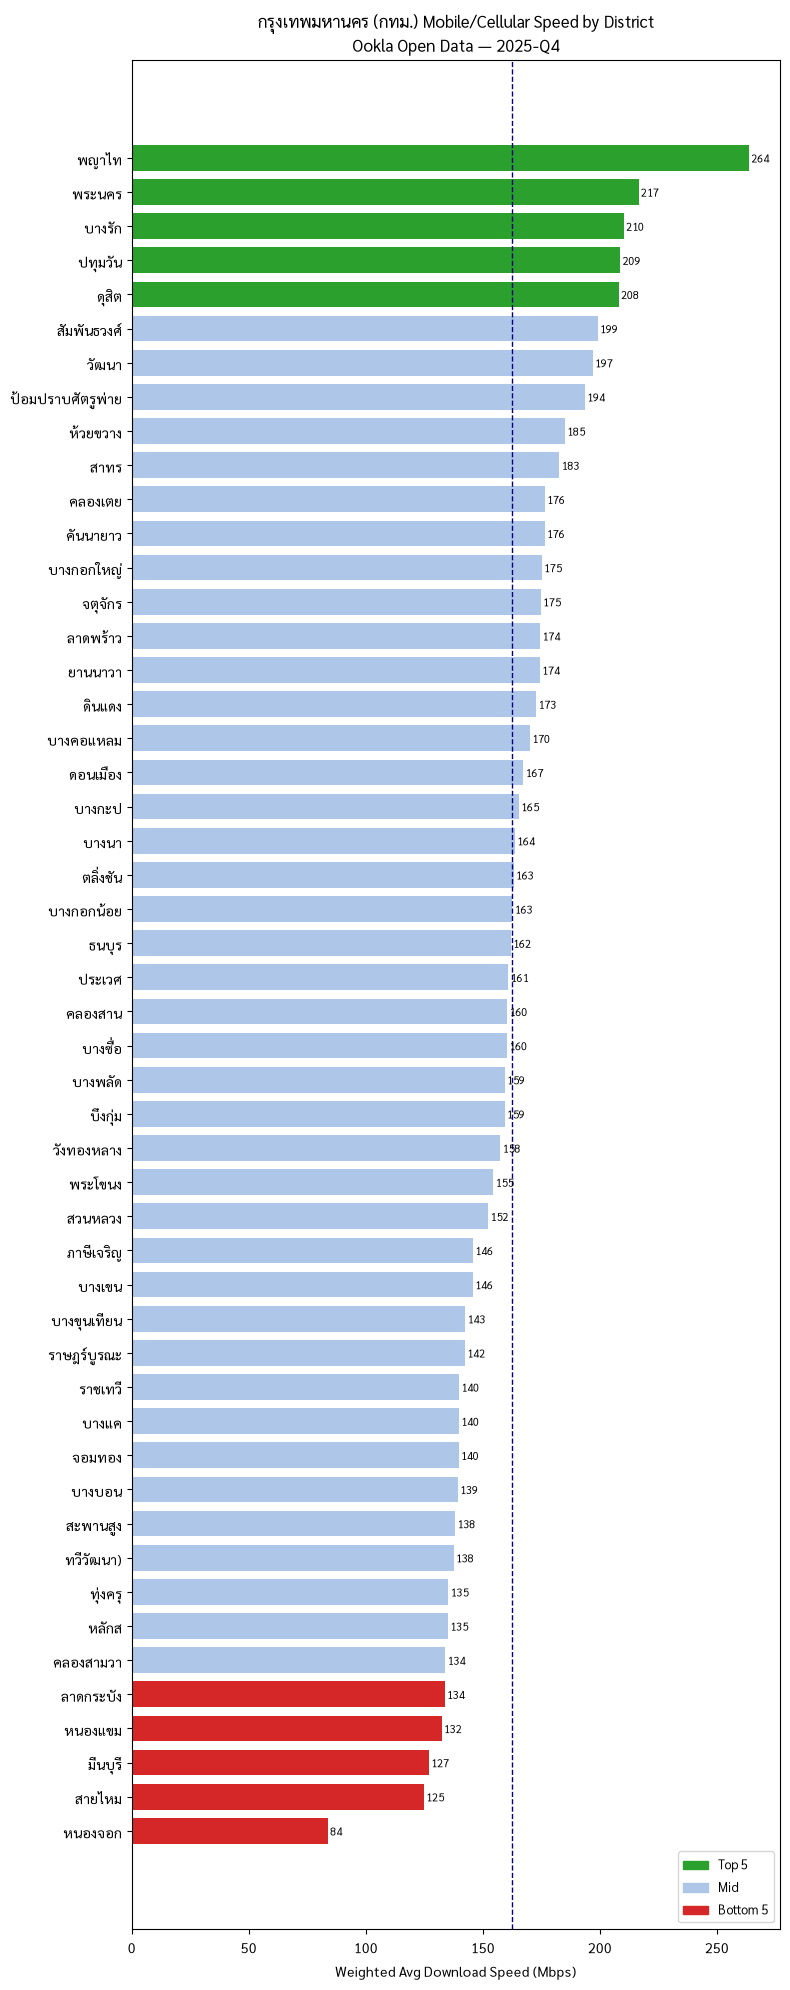

Saved: ../../outputs/ookla/bangkokmetropolis_district_mobile_ranking_2025-Q4.png


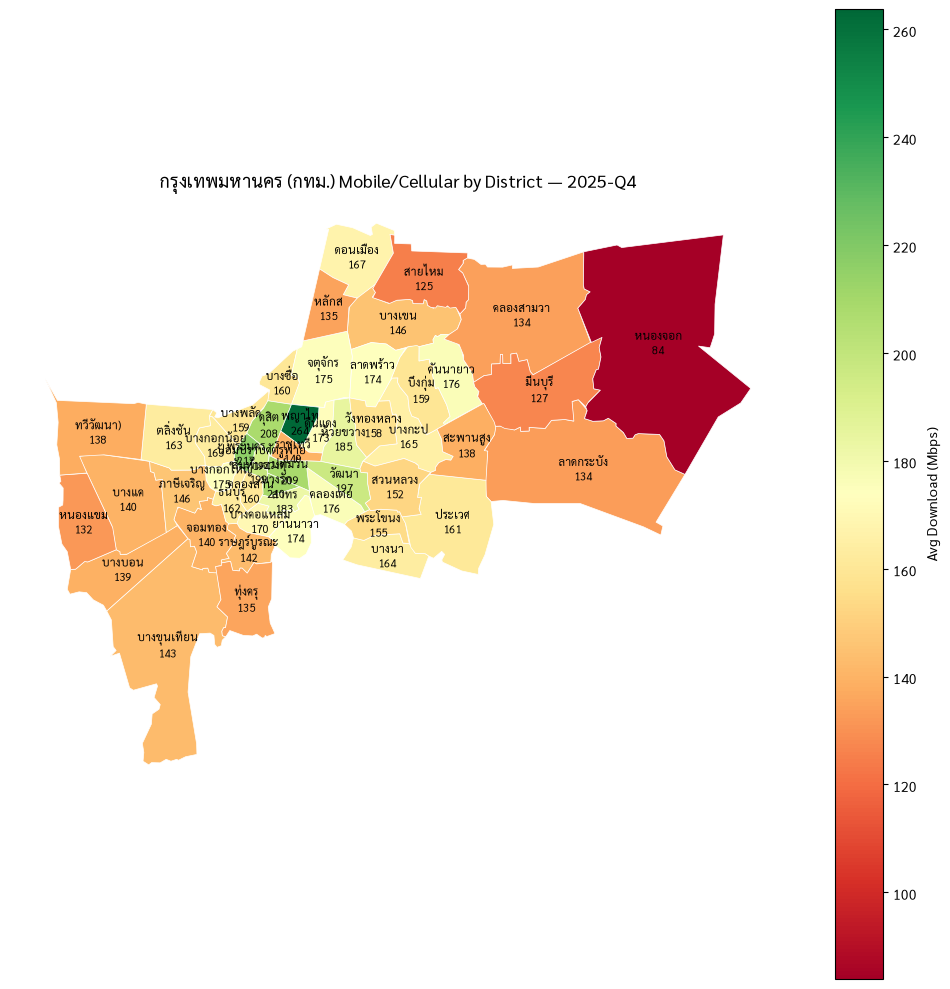

Saved: ../../outputs/ookla/bangkokmetropolis_district_mobile_map_2025-Q4.png
Saved: ../../data/exports/bangkokmetropolis_district_mobile_2025-Q4.csv


In [17]:
stats_bangkok = analyze_province_districts('BangkokMetropolis', 'กรุงเทพมหานคร', 'กทม.')


## นครราชสีมา (โคราช) — Northeastern

=== นครราชสีมา (โคราช) — 32 districts ===
Bbox: lon 101.1830–103.0140, lat 14.1194–15.8065
Tiles in bbox: 5,028
Tiles matched to districts: 3,436 | Districts covered: 32/32



=== TOP 5 (นครราชสีมา (โคราช)) ===
 rank               name_en         name_th  avg_d_mbps  total_tests
    1          PakThongChai        ปักธงชัย  632.914326       2100.0
    2 MuangNakhonRatchasima เมืองนครราชสีมา  374.943589      25008.0
    3              PakChong         ปากช่อง  280.533625       4141.0
    4              ChokChai          โชคชัย  267.506744        852.0
    5               NonSung          โนนสูง  218.551668        802.0

=== BOTTOM 5 (นครราชสีมา (โคราช)) ===
 rank         name_en        name_th  avg_d_mbps  total_tests
   28  KaengSanamNang    แก้งสนามนาง   78.164788        151.0
   29     HuaiThalang       ห้วยแถลง   76.273723        101.0
   30 K.LamThaMenChai กิ่งลำทะเมนชัย   72.822377         69.0
   31          Sikhiu         สีคิ้ว   72.073566        744.0
   32         NonThai         โนนไทย   70.524428        215.0


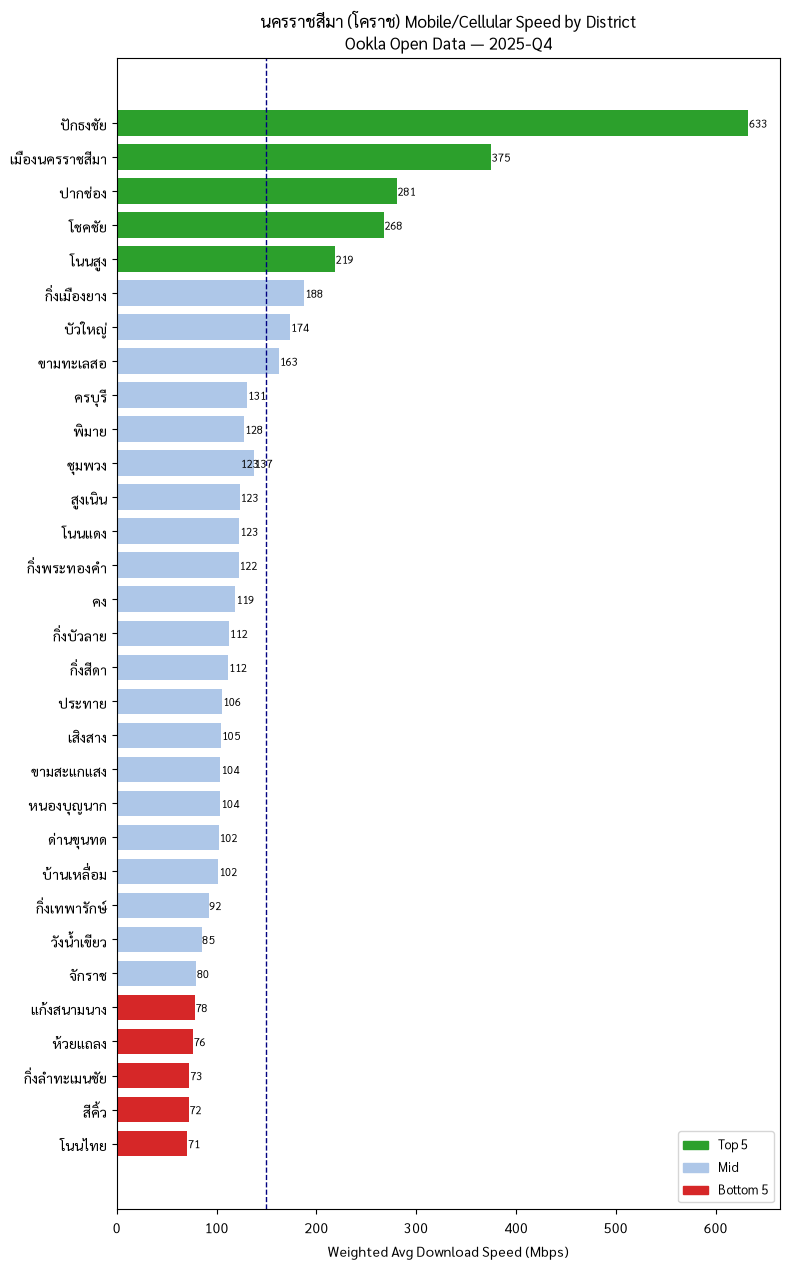

Saved: ../../outputs/ookla/nakhonratchasima_district_mobile_ranking_2025-Q4.png


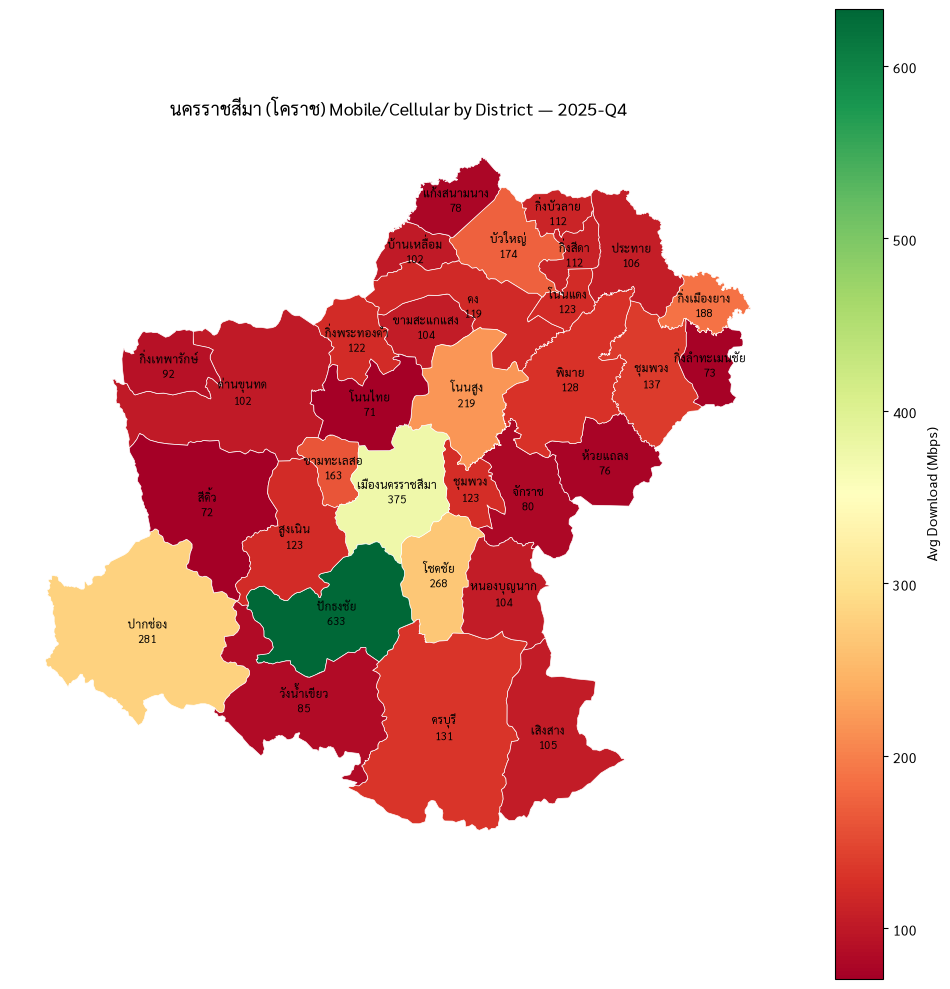

Saved: ../../outputs/ookla/nakhonratchasima_district_mobile_map_2025-Q4.png
Saved: ../../data/exports/nakhonratchasima_district_mobile_2025-Q4.csv


In [18]:
stats_nakhonratchasima = analyze_province_districts('NakhonRatchasima', 'นครราชสีมา', 'โคราช')


## ขอนแก่น — Northeastern

=== ขอนแก่น — 26 districts ===
Bbox: lon 101.7497–103.1880, lat 15.6309–17.0872
Tiles in bbox: 2,832


Tiles matched to districts: 1,524 | Districts covered: 26/26



=== TOP 5 (ขอนแก่น) ===
 rank       name_en      name_th  avg_d_mbps  total_tests
    1 MuangKhonKaen เมืองขอนแก่น  462.061265      13317.0
    2          Phon           พล  439.292158        533.0
    3       BanPhai      บ้านไผ่  191.715822        669.0
    4     K.SamSung    กิ่งซำสูง  152.869059         34.0
    5      WaengYai      แวงใหญ่  137.556208         48.0

=== BOTTOM 5 (ขอนแก่น) ===
 rank      name_en         name_th  avg_d_mbps  total_tests
   22 K.KhokPhoCha กิ่งโคกโพธิ์ชัย   74.734667         24.0
   23     PhupaMan        ภูผาม่าน   69.814198         86.0
   24     PhuWiang         ภูเวียง   66.723206         68.0
   25      PhraYun          พระยืน   62.733301        103.0
   26     WaengNoi         แวงน้อย   51.942674         43.0


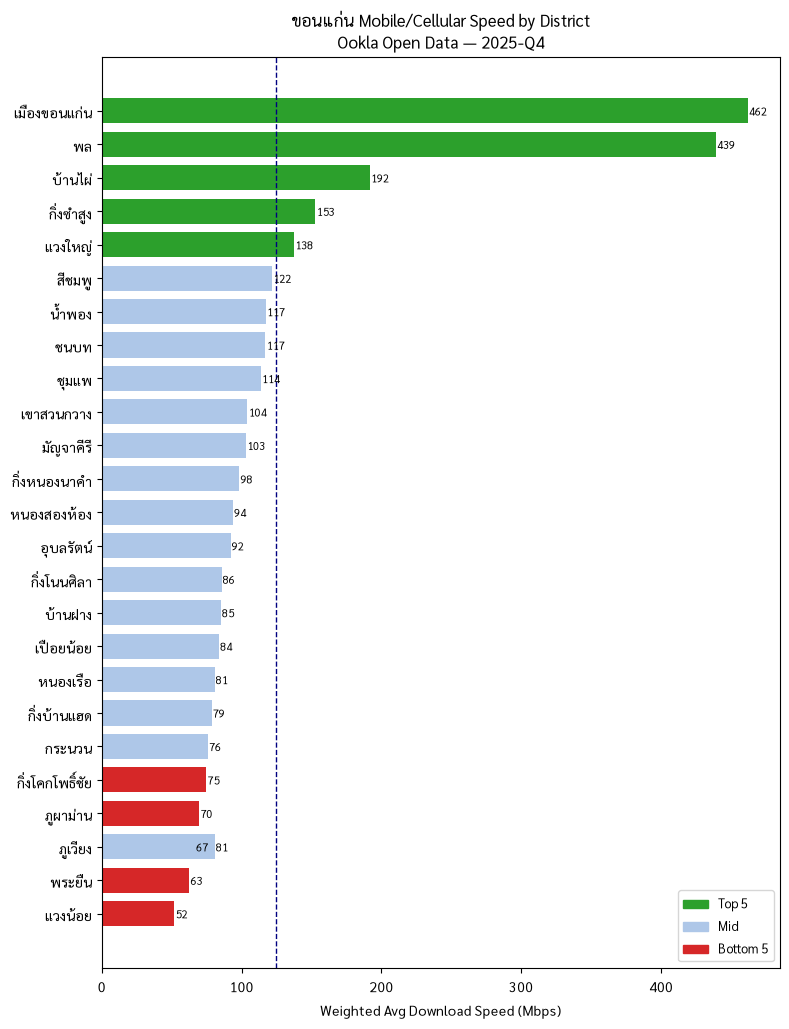

Saved: ../../outputs/ookla/khonkaen_district_mobile_ranking_2025-Q4.png


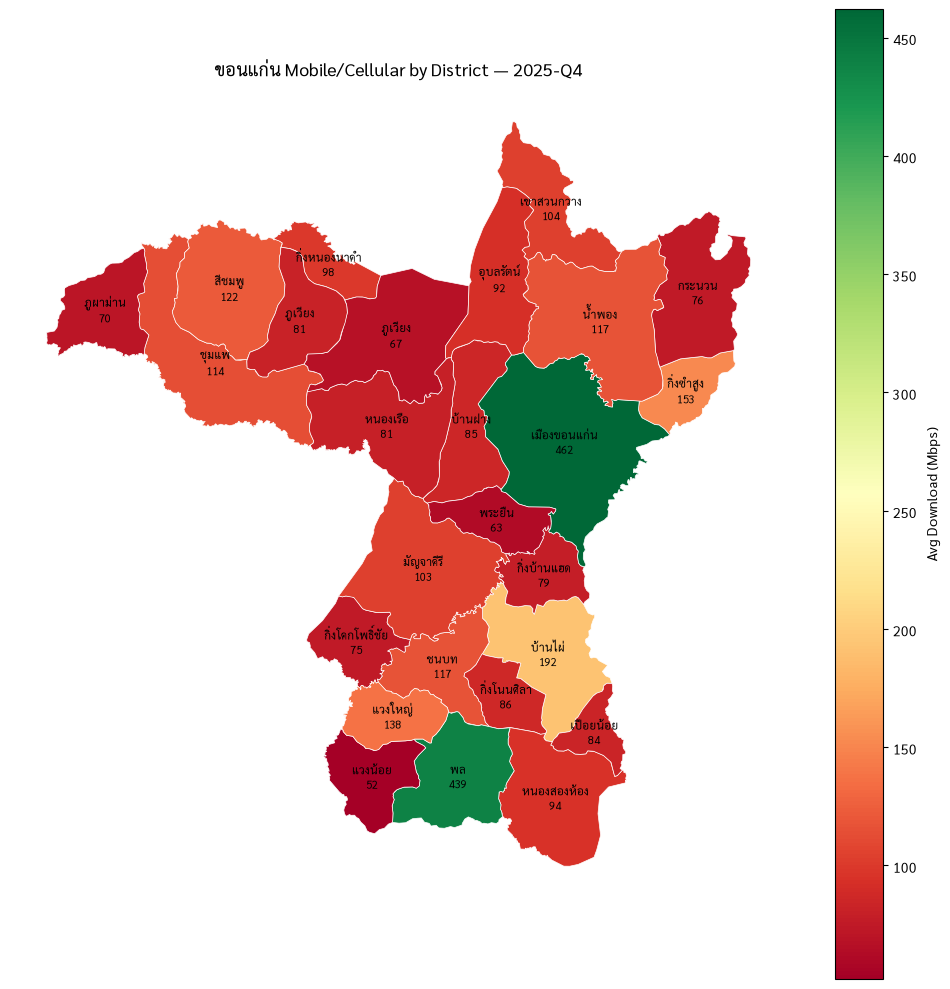

Saved: ../../outputs/ookla/khonkaen_district_mobile_map_2025-Q4.png
Saved: ../../data/exports/khonkaen_district_mobile_2025-Q4.csv


In [19]:
stats_khonkaen = analyze_province_districts('KhonKaen', 'ขอนแก่น', None)


## เชียงใหม่ — Northern

=== เชียงใหม่ — 24 districts ===
Bbox: lon 98.0098–99.5739, lat 17.2727–20.1442
Tiles in bbox: 4,150


Tiles matched to districts: 2,644 | Districts covered: 24/24



=== TOP 5 (เชียงใหม่) ===
 rank        name_en        name_th  avg_d_mbps  total_tests
    1        Samoeng         สะเมิง  215.223116        232.0
    2 MuangChiangMai เมืองเชียงใหม่  145.500893       7119.0
    3        K.MaeOn     กิ่งแม่ออน  136.300315        124.0
    4      SanPaTong      สันป่าตอง  112.510497        350.0
    5         MaeRim         แม่ริม  110.388622       1546.0

=== BOTTOM 5 (เชียงใหม่) ===
 rank name_en name_th  avg_d_mbps  total_tests
   20 MaeWang  แม่วาง   60.880454        130.0
   21     Hot     ฮอด   55.926345        165.0
   22   MaeAi  แม่อาย   48.283699        389.0
   23  DoiTao ดอยเต่า   46.597927         55.0
   24   Omkoi  อมก๋อย   31.292281         64.0


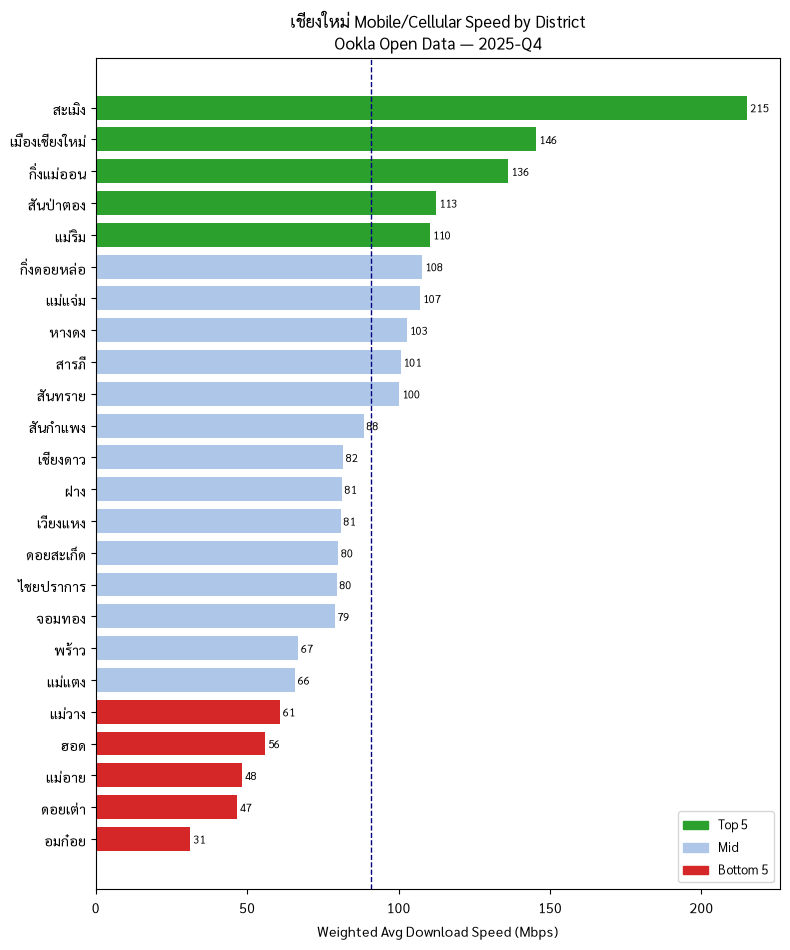

Saved: ../../outputs/ookla/chiangmai_district_mobile_ranking_2025-Q4.png


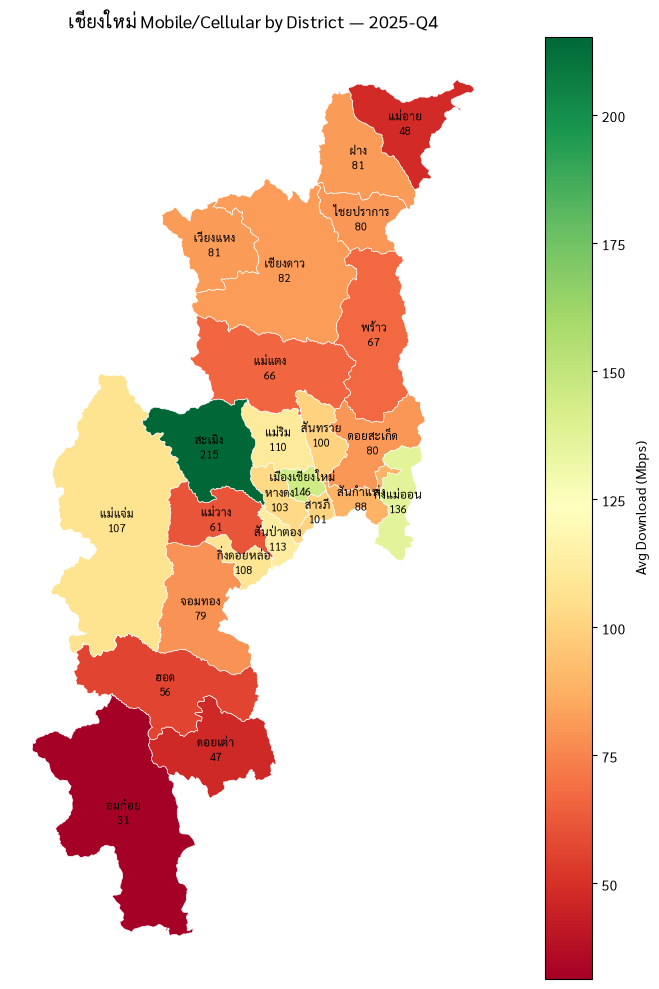

Saved: ../../outputs/ookla/chiangmai_district_mobile_map_2025-Q4.png
Saved: ../../data/exports/chiangmai_district_mobile_2025-Q4.csv


In [20]:
stats_chiangmai = analyze_province_districts('ChiangMai', 'เชียงใหม่', None)


## ภูเก็ต — Southern

=== ภูเก็ต — 3 districts ===
Bbox: lon 98.2581–98.6162, lat 7.4613–8.1999
Tiles in bbox: 882
Tiles matched to districts: 744 | Districts covered: 3/3



=== TOP 1 (ภูเก็ต) ===
 rank name_en name_th  avg_d_mbps  total_tests
    1   Kathu   กะทู้  192.466097       2644.0

=== BOTTOM 1 (ภูเก็ต) ===
 rank name_en name_th  avg_d_mbps  total_tests
    3 Thalang    ถลาง  160.865538       3704.0


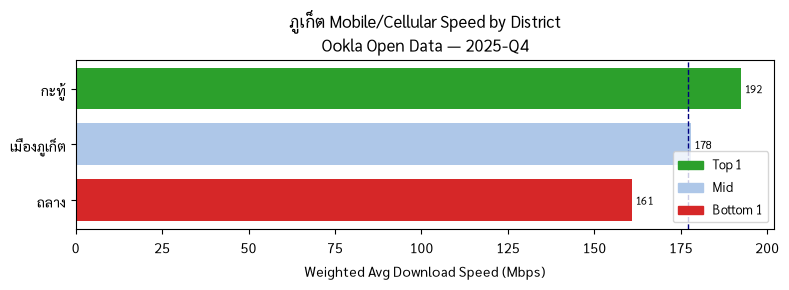

Saved: ../../outputs/ookla/phuket_district_mobile_ranking_2025-Q4.png


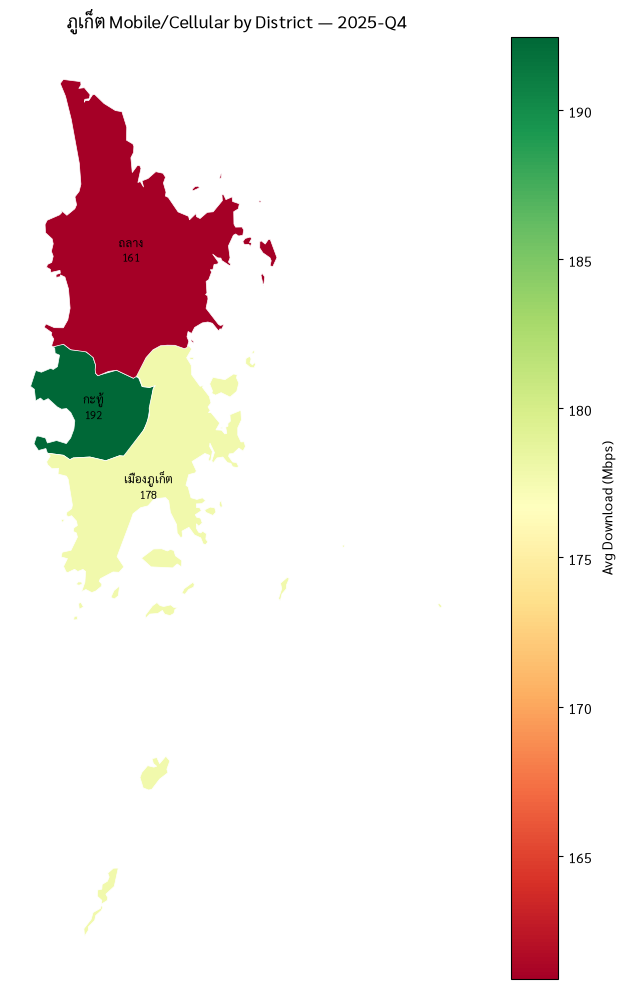

Saved: ../../outputs/ookla/phuket_district_mobile_map_2025-Q4.png
Saved: ../../data/exports/phuket_district_mobile_2025-Q4.csv


In [21]:
stats_phuket = analyze_province_districts('Phuket', 'ภูเก็ต', None)


## ชลบุรี — Eastern (EEC)

=== ชลบุรี — 11 districts ===
Bbox: lon 100.6477–101.7201, lat 12.5079–13.5986
Tiles in bbox: 6,479


Tiles matched to districts: 3,335 | Districts covered: 11/11



=== TOP 5 (ชลบุรี) ===
 rank       name_en     name_th  avg_d_mbps  total_tests
    1    BangLamung    บางละมุง  153.107309      14465.0
    2 MuangChonBuri เมืองชลบุรี  149.954529       7366.0
    3       SiRacha     ศรีราชา  139.606183       8513.0
    4     KoSichang   เกาะสีชัง  129.851793         29.0
    5     PhanThong      พานทอง  118.619904       2074.0

=== BOTTOM 5 (ชลบุรี) ===
 rank      name_en        name_th  avg_d_mbps  total_tests
    7      BanBung        บ้านบึง  102.485684       1716.0
    8 PhanatNikhom       พนัสนิคม   86.270208        824.0
    9      NongYai       หนองใหญ่   84.451955        267.0
   10      BoThong         บ่อทอง   71.426857        230.0
   11     K.KoChan กิ่งเกาะจันทร์   69.686706        177.0


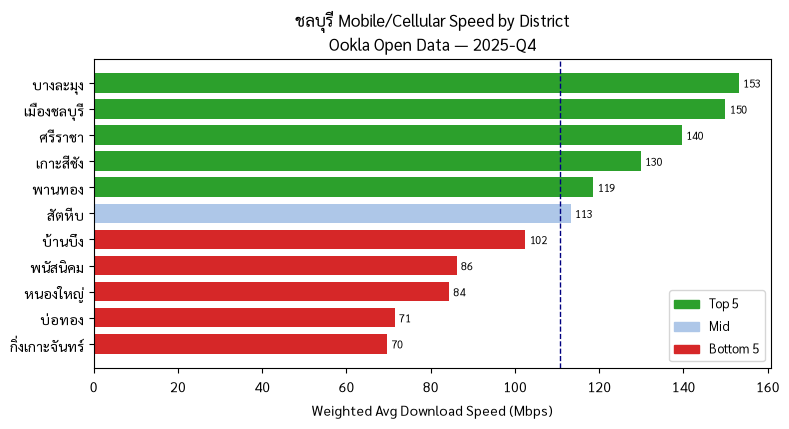

Saved: ../../outputs/ookla/chonburi_district_mobile_ranking_2025-Q4.png


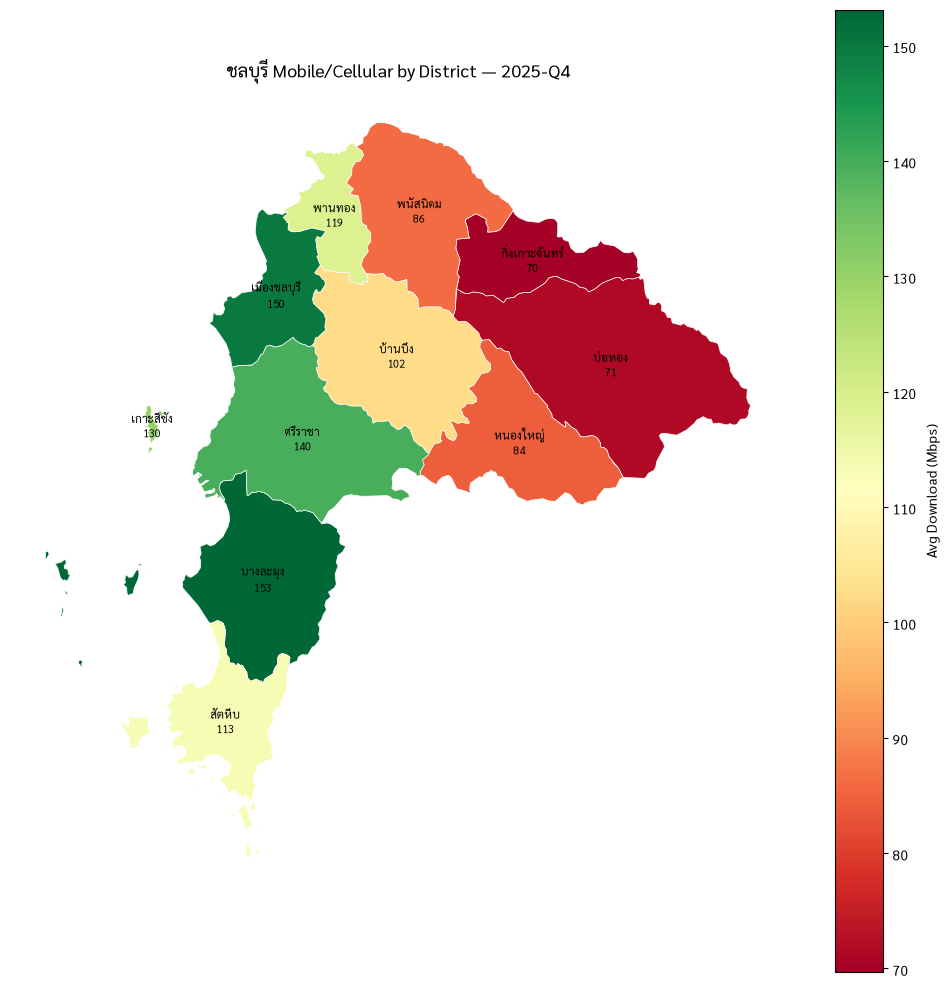

Saved: ../../outputs/ookla/chonburi_district_mobile_map_2025-Q4.png
Saved: ../../data/exports/chonburi_district_mobile_2025-Q4.csv


In [22]:
stats_chonburi = analyze_province_districts('ChonBuri', 'ชลบุรี', None)


## สงขลา — Southern

=== สงขลา — 17 districts ===
Bbox: lon 100.0546–101.1123, lat 6.2887–7.9368
Tiles in bbox: 3,383


Tiles matched to districts: 1,676 | Districts covered: 17/17



=== TOP 5 (สงขลา) ===
 rank       name_en     name_th  avg_d_mbps  total_tests
    1 KhlongHoiKong คลองหอยโข่ง  179.407163        584.0
    2 MuangSongkhla  เมืองสงขลา  139.029435       2428.0
    3        HatYai     หาดใหญ่  120.684733       7696.0
    4       SabaYoi   สะบ้าย้อย  115.652864        338.0
    5     Rattaphum     รัตภูมิ  111.630628        508.0

=== BOTTOM 5 (สงขลา) ===
 rank      name_en     name_th  avg_d_mbps  total_tests
   13 KrasaeSinthu กระแสสินธุ์   65.527000          5.0
   14 SongkhlaLake          NA   58.932000          6.0
   15       Thepha        เทพา   56.501413        206.0
   16        Ranot       ระโนด   54.885973        148.0
   17   KhuanNiang    ควนเนียง   51.255972        107.0


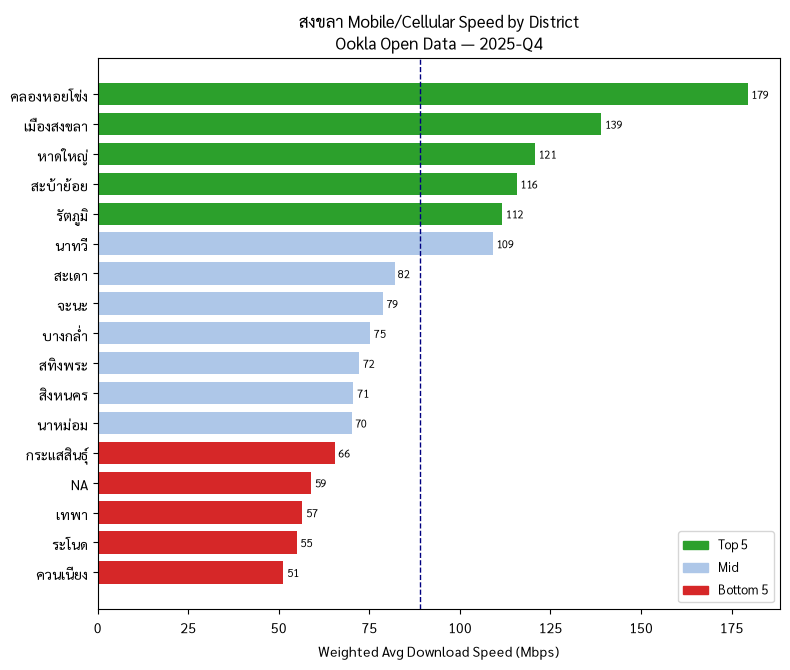

Saved: ../../outputs/ookla/songkhla_district_mobile_ranking_2025-Q4.png


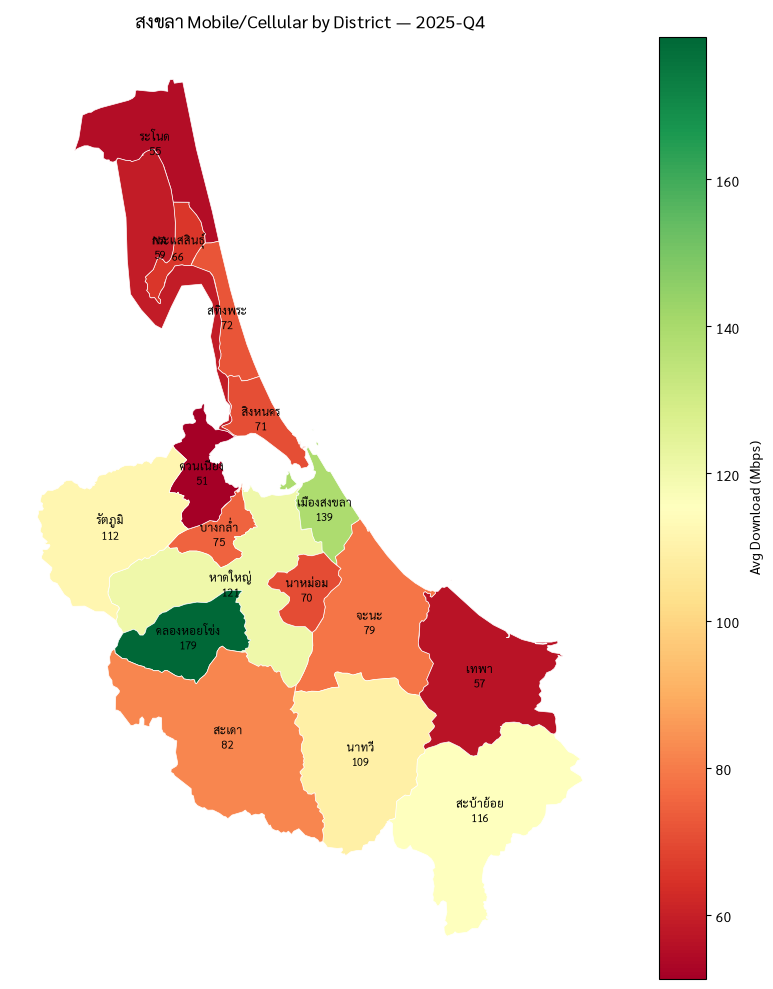

Saved: ../../outputs/ookla/songkhla_district_mobile_map_2025-Q4.png
Saved: ../../data/exports/songkhla_district_mobile_2025-Q4.csv


In [23]:
stats_songkhla = analyze_province_districts('Songkhla', 'สงขลา', None)


## ระยอง — Eastern (EEC)

=== ระยอง — 8 districts ===
Bbox: lon 100.9857–101.8320, lat 12.5127–13.1631
Tiles in bbox: 2,793


Tiles matched to districts: 2,070 | Districts covered: 8/8



=== TOP 4 (ระยอง) ===
 rank      name_en      name_th  avg_d_mbps  total_tests
    1     BanChang      บ้านฉาง  156.427450        836.0
    2  MuangRayong   เมืองระยอง  146.967648       5639.0
    3 K.KhaoChamao กิ่งเขาชะเมา  134.238053         76.0
    4   PluakDaeng      ปลวกแดง  128.597078       4702.0

=== BOTTOM 4 (ระยอง) ===
 rank        name_en       name_th  avg_d_mbps  total_tests
    5 K.NikhomPattan กิ่งนิคมพัฒนา  103.589255        980.0
    6        BanKhai      บ้านค่าย   95.720573        724.0
    7       WangChan     วังจันทร์   93.056597        243.0
    8         Klaeng          แกลง   84.137275        855.0


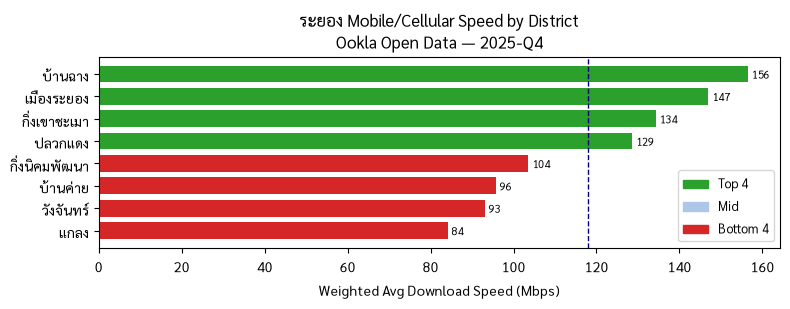

Saved: ../../outputs/ookla/rayong_district_mobile_ranking_2025-Q4.png


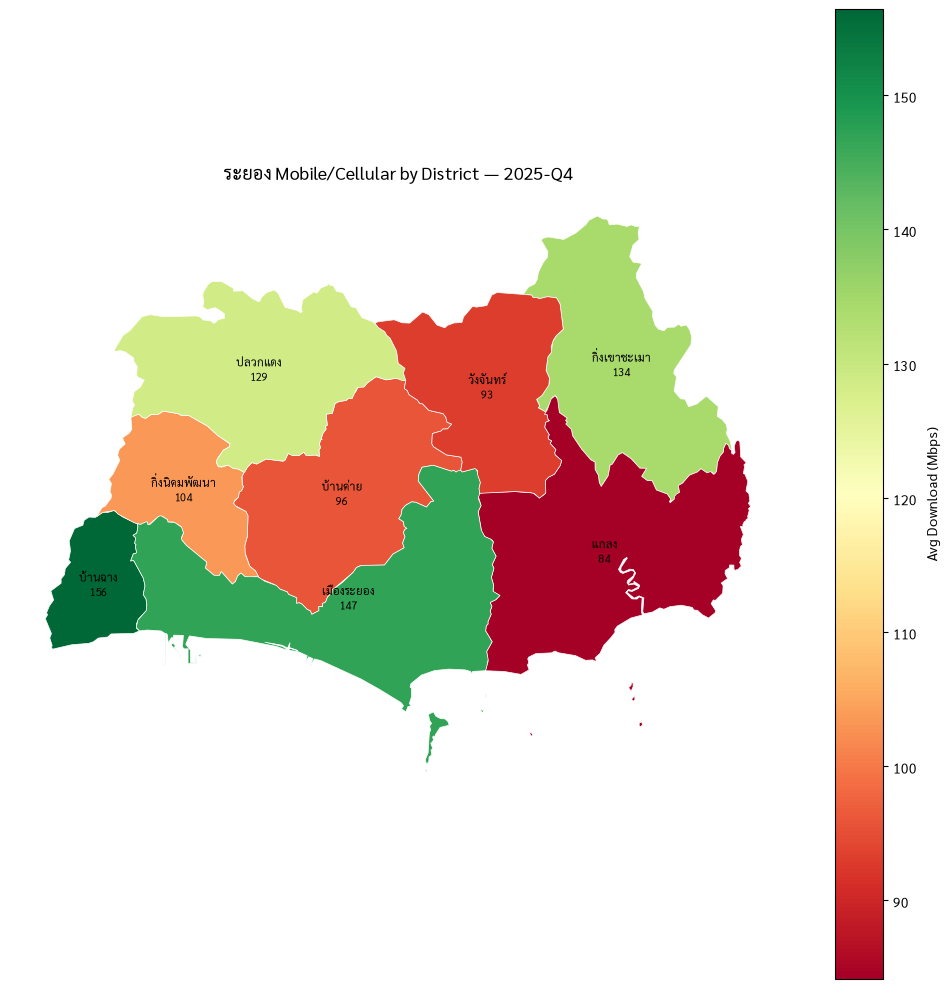

Saved: ../../outputs/ookla/rayong_district_mobile_map_2025-Q4.png
Saved: ../../data/exports/rayong_district_mobile_2025-Q4.csv


In [24]:
stats_rayong = analyze_province_districts('Rayong', 'ระยอง', None)


## Cross-Province Comparison

รวมผลทั้ง 8 จังหวัด เทียบ average download speed ระดับจังหวัด (ถ่วงน้ำหนักจากอำเภอ) เพื่อดูภาพรวมก่อนเทียบกับผล NDT7

      province_en   province_th  avg_d_mbps  total_tests  n_districts  rank
         KhonKaen       ขอนแก่น  383.220952      17840.0         26.0     1
 NakhonRatchasima    นครราชสีมา  336.056602      38257.0         32.0     2
           Phuket        ภูเก็ต  175.883712      12267.0          3.0     3
BangkokMetropolis กรุงเทพมหานคร  164.951324     147770.0         50.0     4
         ChonBuri        ชลบุรี  139.676744      38485.0         11.0     5
           Rayong         ระยอง  130.897101      14055.0          8.0     6
        ChiangMai     เชียงใหม่  116.812504      16424.0         24.0     7
         Songkhla         สงขลา  115.444179      15302.0         17.0     8


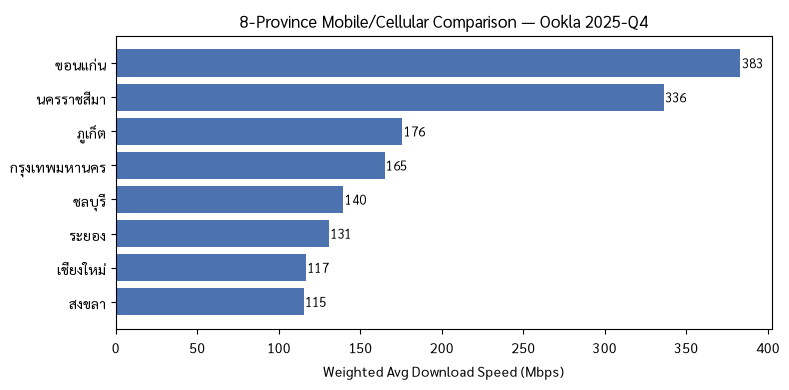

Saved: ../../outputs/ookla/8province_district_mobile_comparison_2025-Q4.png
Saved: ../../data/exports/8province_summary_mobile_2025-Q4.csv


In [25]:
all_stats = pd.concat([stats_bangkok, stats_nakhonratchasima, stats_khonkaen, stats_chiangmai, stats_phuket, stats_chonburi, stats_songkhla, stats_rayong], ignore_index=True)

province_summary = (
    all_stats.groupby(['province_en', 'province_th'])
    .apply(
        lambda x: pd.Series({
            METRIC_MBPS: np.average(x[METRIC_MBPS], weights=x['total_tests']),
            'total_tests': x['total_tests'].sum(),
            'n_districts': len(x),
        }),
        include_groups=False,
    )
    .reset_index()
    .sort_values(METRIC_MBPS, ascending=False)
    .reset_index(drop=True)
)
province_summary['rank'] = province_summary[METRIC_MBPS].rank(ascending=False).astype(int)

print(province_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
df_plot = province_summary.sort_values(METRIC_MBPS, ascending=True)
bars = ax.barh(df_plot['province_th'], df_plot[METRIC_MBPS], color='#4c72b0')
for bar, val in zip(bars, df_plot[METRIC_MBPS]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}', va='center', ha='left', fontsize=9)
ax.set_xlabel('Weighted Avg Download Speed (Mbps)')
ax.set_title(f'8-Province Mobile/Cellular Comparison — Ookla {QUARTER}')
plt.tight_layout()
out = os.path.join(OUTPUT_DIR, f'8province_district_mobile_comparison_{QUARTER}.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

out_csv = os.path.join(EXPORT_DIR, f'8province_summary_mobile_{QUARTER}.csv')
all_stats.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')
